### Read individual .csv files with predictions and store as one single .csv

In [4]:
import os
from pathlib import Path
import glob
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
subdir = "/bm_eq_nonoise"

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = subdir + "_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path + subdir).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load into single df
df = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)

# Extract raw datetime string from time window directories
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Convert to datetime and insert into dataframe
df["start_dt"] = pd.to_datetime(matches["start_dt"], format="%Y%m%dT%H%M%SZ")
df["end_dt"] = pd.to_datetime(matches["end_dt"], format="%Y%m%dT%H%M%SZ")

# Insert correct network code
df["network"] = df["file_name"].str.extract(r'/(.*?)\.')

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
#df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
df.to_csv(csv_output_path + csv_output_name, index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} predictions from {num_files} files.")
print(f"Number of p-arrivals: {num_p_picks}\nNumber of s-arrivals: {num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 4892 predictions from 2988 files.
Number of p-arrivals: 2603
Number of s-arrivals: 1627
Number of empty predictions: 2289


### Plot waveforms and predicted p/s picks

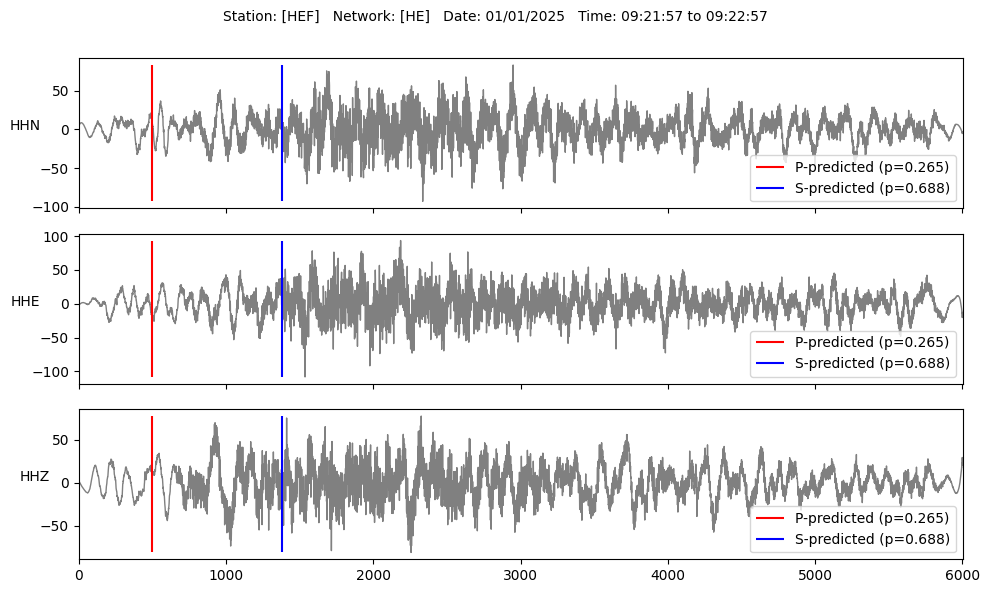

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


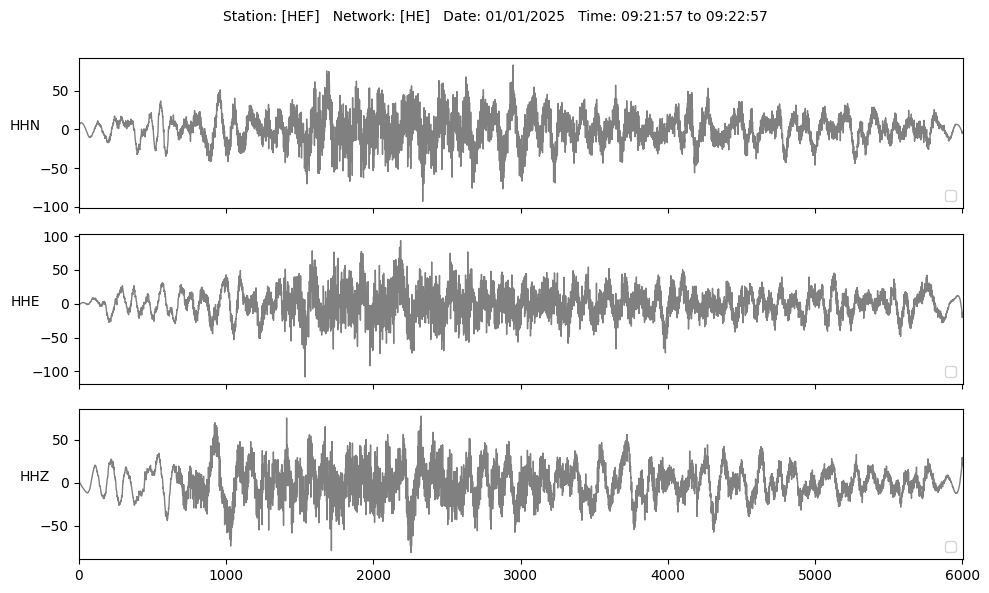

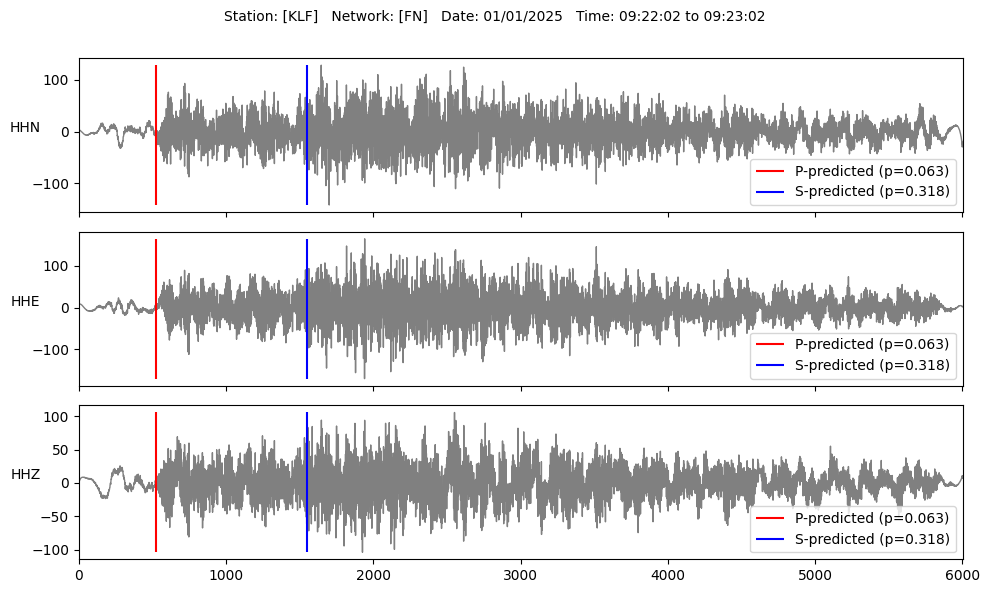

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


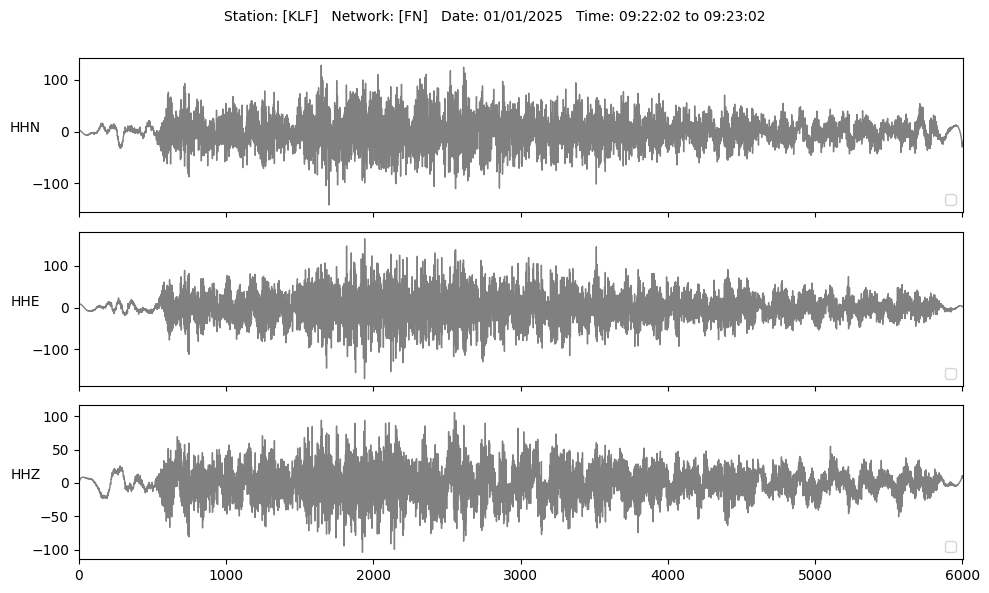

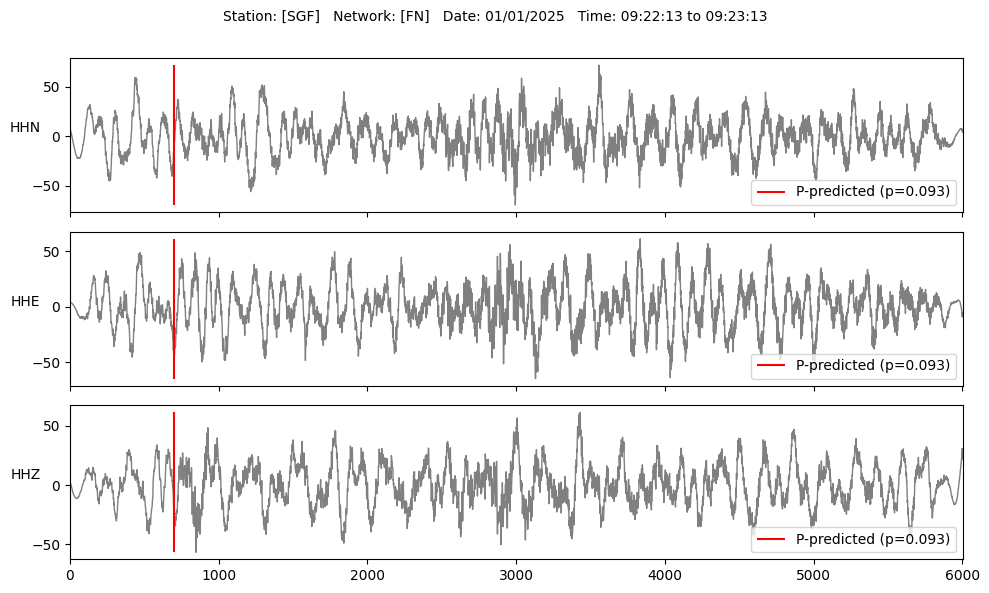

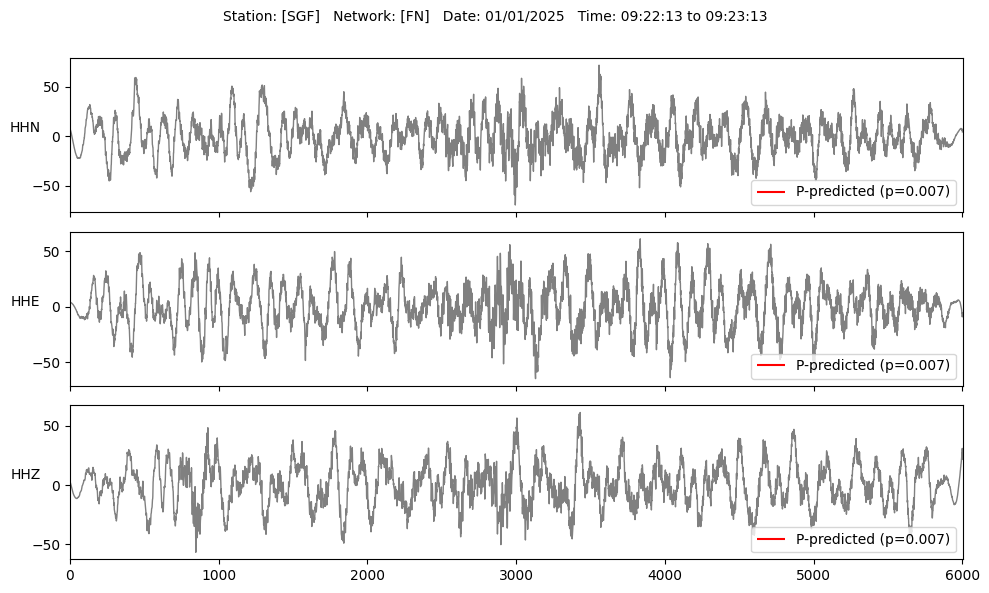

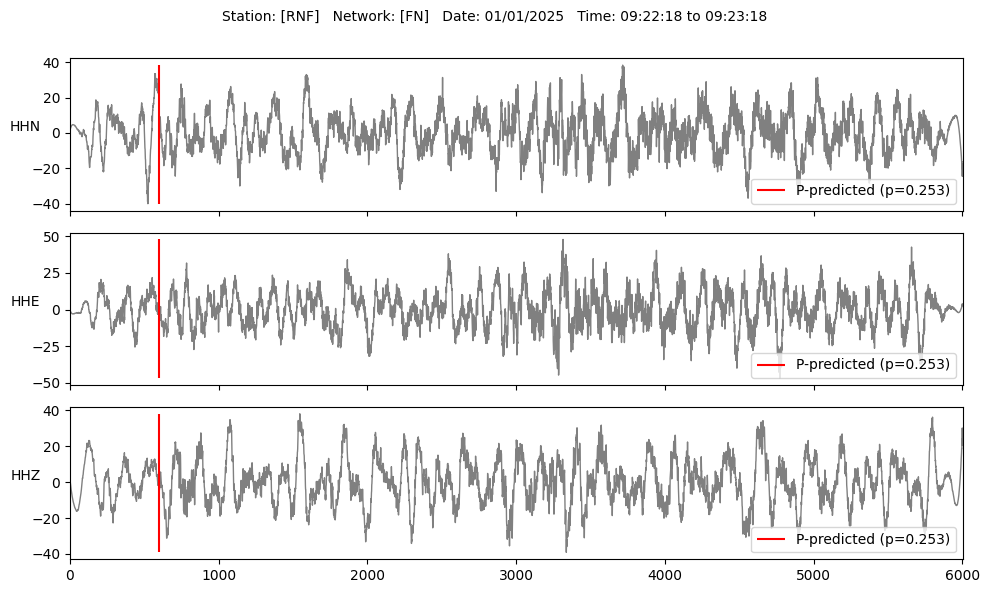

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


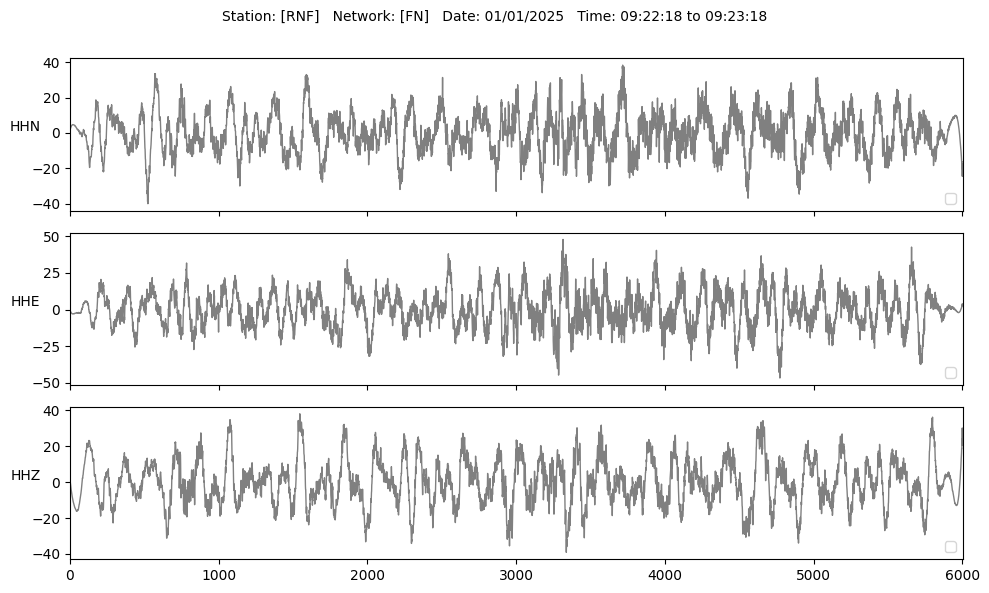

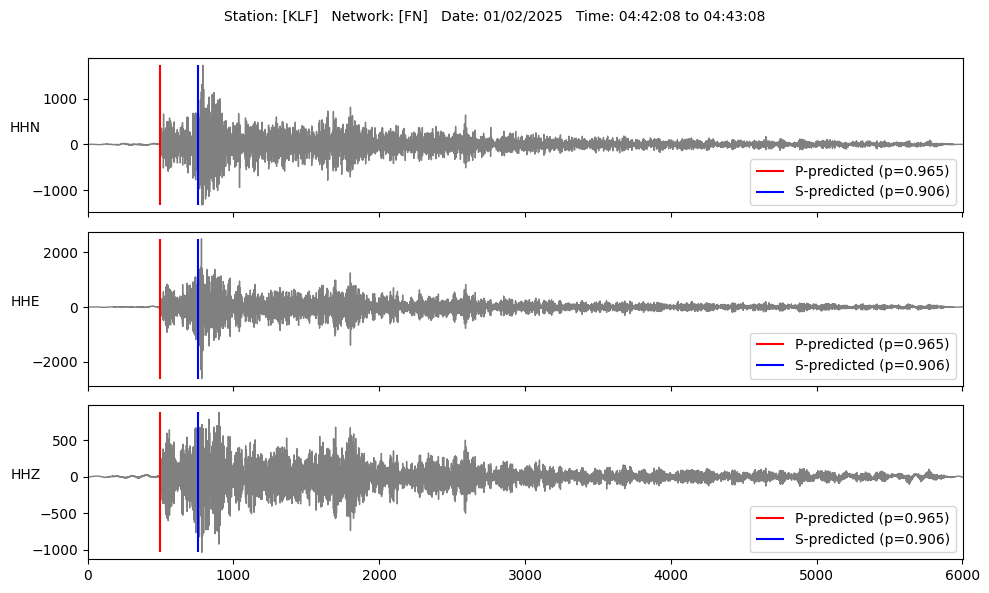

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


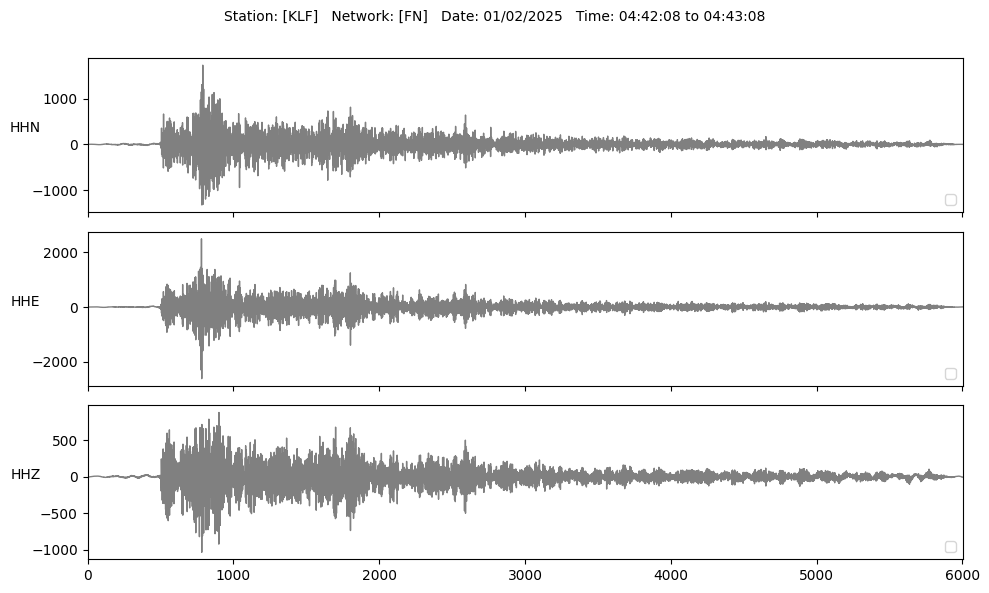

In [5]:
import re
from obspy import UTCDateTime

# Helper function for choosing the time of the trace
def add_time(dt, hours=0, minutes=0, seconds=0):
    return dt + hours * 3600 + minutes * 60 + seconds

# Path for .mseed data
data_dir = "../data/waveforms_earthquakes_nonoise/"
df = pd.read_csv(csv_output_path + csv_output_name)

# Extract information from filename to look for corresponding .mseed files
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Currently predictions are seemingly only for one of three channels
# This is a workaround for loading all three channels
channels = ["HHN", "HHE", "HHZ"]

for i in range(10):
    # Strings for assembling the filename
    station = matches["station"][i]
    network = matches["network"][i]
    start_dt = matches["start_dt"][i]
    end_dt = matches["end_dt"][i]

    # Construct the time window folder
    time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")

    st = []

    for channel in channels:
        # Create filepath for each channel
        filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
        filepath = os.path.join(time_window_dir, filename)

        # Add each channel to the stream (if available)
        if os.path.exists(filepath):
            st += read(filepath)
        else:
            print(f"Warning: {filepath} not found")

    # Extract date and time information
    starttime = st[0].stats.starttime
    endtime = st[0].stats.endtime
    window_date = starttime.strftime("%m/%d/%Y")
    window_start = starttime.strftime("%H:%M:%S")
    window_end = endtime.strftime("%H:%M:%S")

    # Get sampling rate
    sampling_rate = st[0].stats.sampling_rate
    
    # If there is a predicted arrival time, set the picks by computing the waveform sample index
    refP = None
    refS = None
    if pd.notna(df["p_arrival_time"][i]):
        refP = int((UTCDateTime(df["p_arrival_time"][i]) - starttime) * sampling_rate)

    if pd.notna(df["s_arrival_time"][i]):
        refS = int((UTCDateTime(df["s_arrival_time"][i]) - starttime) * sampling_rate)
    
    # === Plotting ===
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
    # Event info to generate a plot title
    event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
    fig.suptitle(event_info,fontsize=10)

    for j, channel in enumerate(channels):
        # Copy the trace for processing
        tr_filt = st[j].copy()

        # Processing/filtering
        tr_filt.detrend("linear")
        tr_filt.detrend("demean")
        tr_filt.taper(max_percentage=0.05)
        tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

        ax = axes[j]
        ax.plot(tr_filt.data, color="grey", linewidth=1)
        
        # Get the min and max y values
        y_min = tr_filt.data.min()
        y_max = tr_filt.data.max()
        
        # Plot vertical lines for predicted p- and s-wave arrivals
        if refP:
            ax.vlines(refP, y_min, y_max, color='r', linewidth=1.5, label=f'P-predicted (p={df["p_probability"][i]})')

        if refS:
            ax.vlines(refS, y_min, y_max, color='b', linewidth=1.5, label=f'S-predicted (p={df["s_probability"][i]})')

        # Set x limit
        ax.set_xlim(0, len(tr_filt.data))
        ax.set_ylabel(channel, rotation="horizontal")
        ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### Load quake-ML files with true picks

In [6]:
from obspy import read_events
import geopandas as gpd
from shapely.geometry import Point

In [7]:
qml_dir = Path("../data/qml_files")

paths = {
    "earthquakes": qml_dir / "earthquakes2025.qkml",
    "explosions": qml_dir / "explosions2025.qkml",
    "probable_explosions": qml_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml


### Look at .qml event information

In [8]:
# Earthquake events catalog
eq_cat = catalogs["earthquakes"]
print(eq_cat)

# Inspect a single event by index
i = 0
event = eq_cat[i]
print(f"\nSingle event (index = {i}):")
print(event)
print("origins:", len(event.origins))          # number of location solutions
print("magnitudes:", len(event.magnitudes))    # number of magnitude estimates
print("picks:", len(event.picks))              # total phase picks across stations
print("comments:", event.comments)

for pick in event.picks:
    print(pick)

328 Event(s) in Catalog:
2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML
2025-01-02T04:42:09.800000Z | +67.059,  +24.110 | 0.2  ML
...
2025-12-28T22:31:37.900000Z | +65.044,  +27.374 | 1.1  ML
2025-12-30T11:43:17.500000Z | +61.567,  +24.258 | 1.1  ML
To see all events call 'print(CatalogObject.__str__(print_all=True))'

Single event (index = 0):
Event:	2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML

	            resource_id: ResourceIdentifier(id="smi:fi.isuh/event/1490639")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:fi.isuh/origin/1490639")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:fi.isuh/magnitude/1490639")
	                   ---------
	     event_descriptions: 1 Elements
	               comments: 3 Elements
	                  picks: 18 Elements
	             amplitudes: 3 Elements
	       focal_mechanisms: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements
origins: 1


In [23]:
# Get information about the catalogue: earliest and latest pick
pick_times = [
    pick.time
    for event in eq_cat
    for pick in event.picks
]

# Set of networks
networks = {
    pick.waveform_id.network_code
    for event in eq_cat
    for pick in event.picks
    if pick.waveform_id
}

# Set of stations
stations = {
    pick.waveform_id.station_code
    for event in eq_cat
    for pick in event.picks
    if pick.waveform_id
}

print(f"Earliest pick: {min(pick_times)}\nLatest pick: {max(pick_times)}")
print(f"Networks:\n{sorted(networks)}")
print(f"Stations:\n{sorted(stations)}")

Earliest pick: 2025-01-01T09:22:01.256470Z
Latest pick: 2025-12-30T11:44:33.362750Z
Networks:
['', 'EE', 'FN', 'GE', 'HE', 'NO', 'NS', 'UP']
Stations:
['AAL', 'ALAJF', 'ARA0', 'ARBE', 'ARNU', 'BEA1', 'BLMU', 'BURU', 'ECKF', 'EE04', 'EE06', 'ERTU', 'FAUS', 'FIA0', 'FIA1', 'FLYU', 'FOO', 'GILDE', 'GOTU', 'GRAU', 'HAMF', 'HEF', 'HEL1', 'HEL5', 'HEMU', 'HUSU', 'JETT', 'JOF', 'KAF', 'KALU', 'KEF', 'KEV', 'KIF', 'KJNF', 'KLF', 'KMNF', 'KOFF', 'KONS', 'KORF', 'KPF', 'KTK1', 'KU1', 'KU2', 'KU6', 'KUNI', 'KY02', 'KY17', 'LANU', 'LAUT', 'LEIR', 'LENS', 'LEPP', 'LOF', 'LOSSI', 'LOVF', 'MEF', 'MSF', 'MTSE', 'NIF', 'NOPE', 'NRTU', 'NSS', 'NUR', 'OBF0', 'OBF3', 'OBF8', 'OLKF', 'OUF', 'OUL', 'PAJU', 'PISE', 'PLDE', 'PVF', 'RAF', 'RAJF', 'RANF', 'RMF', 'RNF', 'ROROS', 'RSUO', 'RUF', 'SGF', 'SLIT', 'SRGE', 'STEI', 'STOK', 'SUF', 'TOF', 'TOSE', 'TRE03', 'TRO', 'TVF', 'VADS', 'VAF', 'VAGH', 'VBYGD', 'VJF', 'VRF', 'VSU', 'VUOS']


In [24]:
eq_dir = Path("../data/waveforms_earthquakes_nonoise")

subdirs = []

for d in eq_dir.iterdir():      # A, B, C
    if d.is_dir():
        for sd in d.iterdir():  # 1, 2, ...
            if sd.is_dir():
                subdirs.append(sd)

for s in subdirs:
    print(s)

print("Number of subdirectories:", len(subdirs))

../data/waveforms_earthquakes_nonoise/20250711T140107Z_20250711T140207Z/RANF
../data/waveforms_earthquakes_nonoise/20250215T210112Z_20250215T210212Z/KU6
../data/waveforms_earthquakes_nonoise/20250713T192016Z_20250713T192116Z/SGF
../data/waveforms_earthquakes_nonoise/20250512T031148Z_20250512T031248Z/OUL
../data/waveforms_earthquakes_nonoise/20250305T093540Z_20250305T093640Z/OUL
../data/waveforms_earthquakes_nonoise/20250704T153059Z_20250704T153159Z/NUR
../data/waveforms_earthquakes_nonoise/20250423T183507Z_20250423T183607Z/OBF0
../data/waveforms_earthquakes_nonoise/20250802T203600Z_20250802T203700Z/RNF
../data/waveforms_earthquakes_nonoise/20251021T034312Z_20251021T034412Z/VRF
../data/waveforms_earthquakes_nonoise/20250914T060230Z_20250914T060330Z/SUF
../data/waveforms_earthquakes_nonoise/20250131T023215Z_20250131T023315Z/TOF
../data/waveforms_earthquakes_nonoise/20251117T222955Z_20251117T223055Z/TOF
../data/waveforms_earthquakes_nonoise/20251027T195024Z_20251027T195124Z/KPF
../data/wa

### Compile true p- and s-picks into dataframe

In [10]:
# Create a dictionary only for networks/stations contained in predictions
network_list = ["HE", "FN","UP"]
station_dict = dict.fromkeys(["HE", "FN","UP"])
for ntwk in network_list:
    station_dict[ntwk] = df[matches["network"] == ntwk]["station"].unique()

In [33]:
station_dict

{'HE': array(['HEF ', 'TOF ', 'OBF8', 'OBF0', 'OUF ', 'VAF ', 'OBF3', 'ALAJF',
        'SUF ', 'NIF ', 'KIF ', 'KPF ', 'RAF ', 'KU6 ', 'VRF ', 'RMF ',
        'VJF ', 'FIA0', 'FIA1', 'VUOS', 'KUNI', 'LAUT', 'HEL1', 'RUF ',
        'MEF ', 'KAF ', 'KEF ', 'TVF ', 'NUR ', 'HEL5', 'KEV ', 'JOF ',
        'RSUO'], dtype=object),
 'FN': array(['KLF ', 'SGF ', 'RNF ', 'RANF', 'OUL ', 'MSF ', 'OLKF', 'RAJF',
        'KMNF'], dtype=object),
 'UP': array(['AAL '], dtype=object)}

In [34]:
# Extract picks from earthquake catalogue
p_alias = {"P", "PG", "PB", "PN"}
s_alias = {"S", "SG", "SB", "SN"}

times = []
networks = []
stations = []
phases = []
event_ids = []

for event in eq_cat:
    event_id = event.resource_id

    # Get pick information per event
    for pick in event.picks:
        pick_time = pick.time
        if pick.waveform_id is None:
            continue
        pick_network = pick.waveform_id.network_code
        pick_station = pick.waveform_id.station_code
        pick_phase_hint = pick.phase_hint

        # Ensure that picks belong to the same list of networks and stations as predictions
        if pick_network in station_dict.keys() and pick_station in station_dict[pick_network]:
            if pick_phase_hint:
                ph = (pick_phase_hint or "").upper().strip()
                if ph in p_alias:
                    pick_phase = "P"
                elif ph in s_alias:
                    pick_phase = "S"
                else:
                    continue
            
            # Append pick information to lists
            times.append(pick_time.datetime)
            networks.append(pick_network)
            stations.append(pick_station)
            phases.append(pick_phase)
            event_ids.append(event_id)

# Compile data to dataframe
df_true = pd.DataFrame({"event_id": event_ids, "arrival_time": times, "network": networks, "station": stations, "phase": phases})

### Match and merge dataframes for predictions and actual picks

In [54]:
# Probability threshold
p_threshold = 0.05

# Split predicted p-arrivals and s-arrivals into dataframes
df_pred = df.sort_values("start_dt")
df_pred_p = df_pred[["network", "station", "p_arrival_time", "p_probability", "start_dt", "end_dt"]].rename(columns={"p_arrival_time": "arrival_time", "p_probability": "probability"})
df_pred_s = df_pred[["network", "station", "s_arrival_time", "s_probability", "start_dt", "end_dt"]].rename(columns={"s_arrival_time": "arrival_time", "s_probability": "probability"})

# Add a phase column
df_pred_p["phase"] = "P"
df_pred_s["phase"] = "S"

# Concatenate into one longer dataframe
df_pred_long = pd.concat([df_pred_p, df_pred_s], ignore_index=True)
df_pred_long = df_pred_long.dropna()
df_pred_long = df_pred_long[df_pred_long["probability"] > p_threshold]

# Convert to standard datetime
df_pred_long["arrival_time"] = pd.to_datetime(df_pred_long["arrival_time"])
df_pred_long["pred_arrival_time"] = df_pred_long["arrival_time"]

# Convert to datetime for true picks as well
df_true["arrival_time"] = pd.to_datetime(df_true["arrival_time"])
df_true["true_arrival_time"] = df_true["arrival_time"]

# Sort by datetime for both
df_pred_long = df_pred_long.sort_values("arrival_time")
df_true = df_true.sort_values("arrival_time")

In [56]:
# How much time between predictions and true picks to accept
delta = pd.Timedelta("2s")

# Dataframe merging predictions on ground truth -> TP and FP
preds_on_picks = pd.merge_asof(
    df_pred_long,
    df_true,
    on="arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

# Dataframe merging ground truth on predictions -> TP and FN
picks_on_preds = pd.merge_asof(
    df_true,
    df_pred_long,
    on="arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

### Early metrics

In [57]:
# "False positives" (Predictions without corresponding event)
FP = preds_on_picks[preds_on_picks["event_id"].isna()]

# True positives (Prediction and event match within the given timedelta)
TP = preds_on_picks[~preds_on_picks["event_id"].isna()]

# False negatives (No prediction for true pick found)
FN = picks_on_preds[picks_on_preds["probability"].isna()]

num_preds = len(df_pred_long)

print(f"True Positives:\t\t{len(TP)}\nFalse Positives:\t{len(FP)}\nFalse Negatives:\t{len(FN)}")
print(f"Total predictions:\t{len(TP) + len(FP)}")

True Positives:		936
False Positives:	2786
False Negatives:	388
Total predictions:	3722


In [58]:
# Filter p and s picks to monitor accuracy difference between the two models
p_picks = preds_on_picks["phase"] == "P"
s_picks = preds_on_picks["phase"] == "S"

# "False positives" (Predictions without corresponding event)
FP_p = preds_on_picks[p_picks & preds_on_picks["event_id"].isna()]
FP_s = preds_on_picks[s_picks & preds_on_picks["event_id"].isna()]

# True positives (Prediction and event match within the given timedelta)
TP_p = preds_on_picks[p_picks & ~preds_on_picks["event_id"].isna()]
TP_s = preds_on_picks[s_picks & ~preds_on_picks["event_id"].isna()]

# False negatives (No prediction for true pick found)
FN_p = picks_on_preds[p_picks & picks_on_preds["probability"].isna()]
FN_s = picks_on_preds[s_picks & picks_on_preds["probability"].isna()]

num_p_preds = len(TP_p) + len(FN_p)
num_s_preds = len(TP_s) + len(FN_s)

print(f"P-Picks:\nTrue positives:\t\t{len(TP_p)}\nFalse negatives:\t{len(FN_p)}\nTotal:\t{num_p_preds}")
print(f"Accuracy: {len(TP_p)/num_p_preds}\n")
print(f"S-Picks:\nTrue positives:\t\t{len(TP_s)}\nFalse negatives:\t{len(FN_s)}\nTotal:\t{num_s_preds}")
print(f"Accuracy: {len(TP_s)/num_s_preds}")

P-Picks:
True positives:		491
False negatives:	226
Total:	717
Accuracy: 0.6847977684797768

S-Picks:
True positives:		445
False negatives:	162
Total:	607
Accuracy: 0.7331136738056013


/home/tomc/miniconda3/envs/eqcct/lib/python3.7/site-packages/ipykernel_launcher.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  
/home/tomc/miniconda3/envs/eqcct/lib/python3.7/site-packages/ipykernel_launcher.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  from ipykernel import kernelapp as app


In [59]:
preds_on_picks

,network,station,arrival_time,probability,start_dt,end_dt,phase,pred_arrival_time,event_id,true_arrival_time
0,HE,HEF,2025-01-01 09:22:02.640,0.265,2025-01-01 09:21:57,2025-01-01 09:22:57,P,2025-01-01 09:22:02.640,NaN,NaT
1,FN,KLF,2025-01-01 09:22:08.020,0.063,2025-01-01 09:22:02,2025-01-01 09:23:02,P,2025-01-01 09:22:08.020,NaN,NaT
2,HE,HEF,2025-01-01 09:22:11.460,0.688,2025-01-01 09:21:57,2025-01-01 09:22:57,S,2025-01-01 09:22:11.460,NaN,NaT
3,FN,KLF,2025-01-01 09:22:18.220,0.318,2025-01-01 09:22:02,2025-01-01 09:23:02,S,2025-01-01 09:22:18.220,NaN,NaT
4,FN,SGF,2025-01-01 09:22:20.000,0.093,2025-01-01 09:22:12,2025-01-01 09:23:12,P,2025-01-01 09:22:20.000,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...
3717,HE,SUF,2025-12-30 11:44:02.520,0.437,2025-12-30 11:43:38,2025-12-30 11:44:38,S,2025-12-30 11:44:02.520,NaN,NaT
3718,HE,ALAJF,2025-12-30 11:44:06.026,0.186,2025-12-30 11:43:41,2025-12-30 11:44:41,S,2025-12-30 11:44:06.026,smi:fi.isuh/event/1560326,2025-12-30 11:44:06.019420
3719,HE,VAF,2025-12-30 11:44:08.750,0.474,2025-12-30 11:43:42,2025-12-30 11:44:42,S,2025-12-30 11:44:08.750,NaN,NaT
3720,HE,TVF,2025-12-30 11:44:11.576,0.061,2025-12-30 11:44:07,2025-12-30 11:45:07,P,2025-12-30 11:44:11.576,NaN,NaT


### Plot predictions versus true picks (only for correct predictions within e.g. 2s)

../data/waveforms_earthquakes_nonoise/20250102T044230Z_20250102T044330Z/RANF


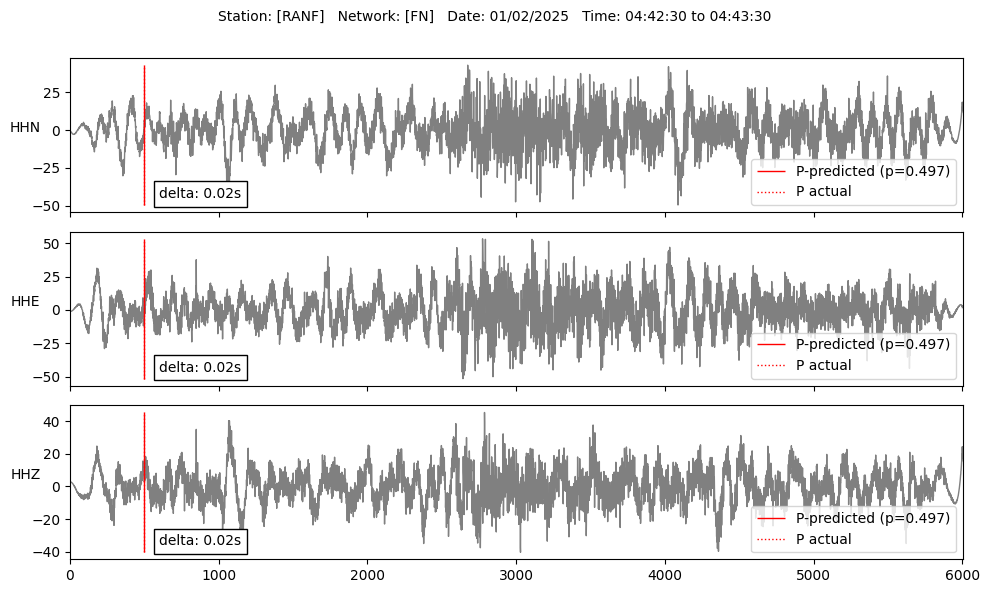

../data/waveforms_earthquakes_nonoise/20250102T044230Z_20250102T044330Z/RANF


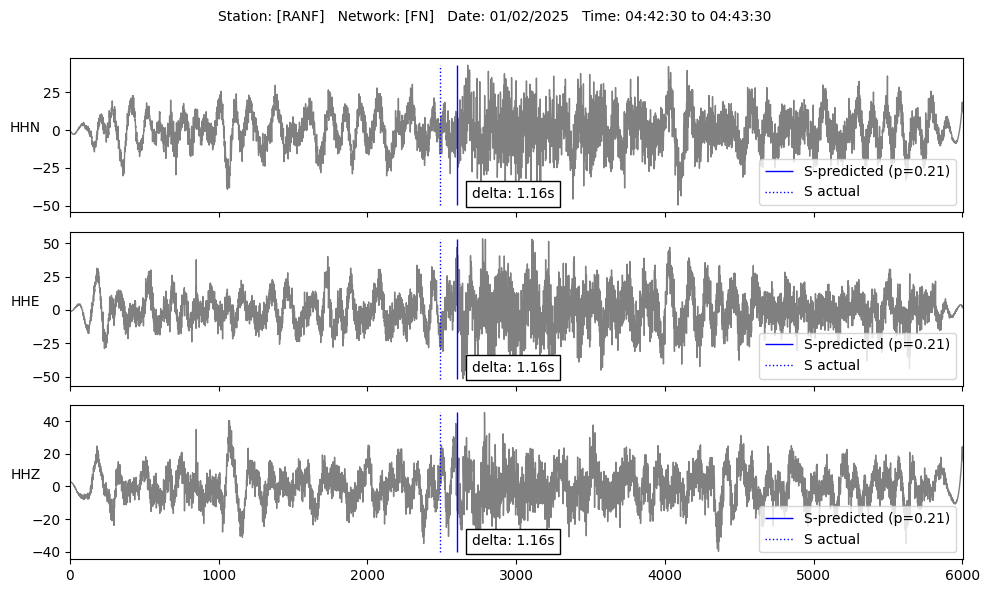

../data/waveforms_earthquakes_nonoise/20250105T045454Z_20250105T045554Z/OBF8


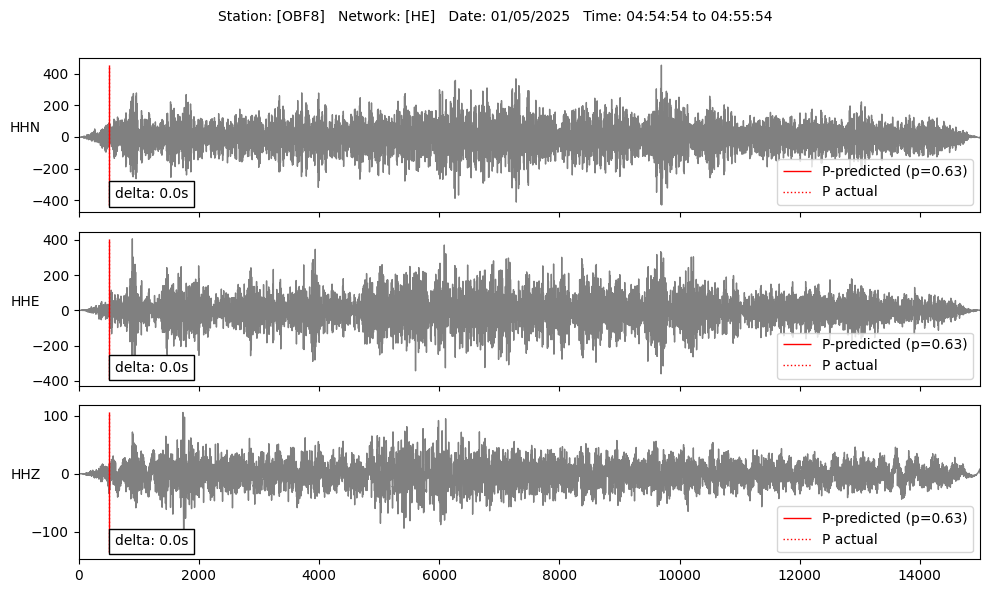

../data/waveforms_earthquakes_nonoise/20250105T045500Z_20250105T045600Z/OBF0


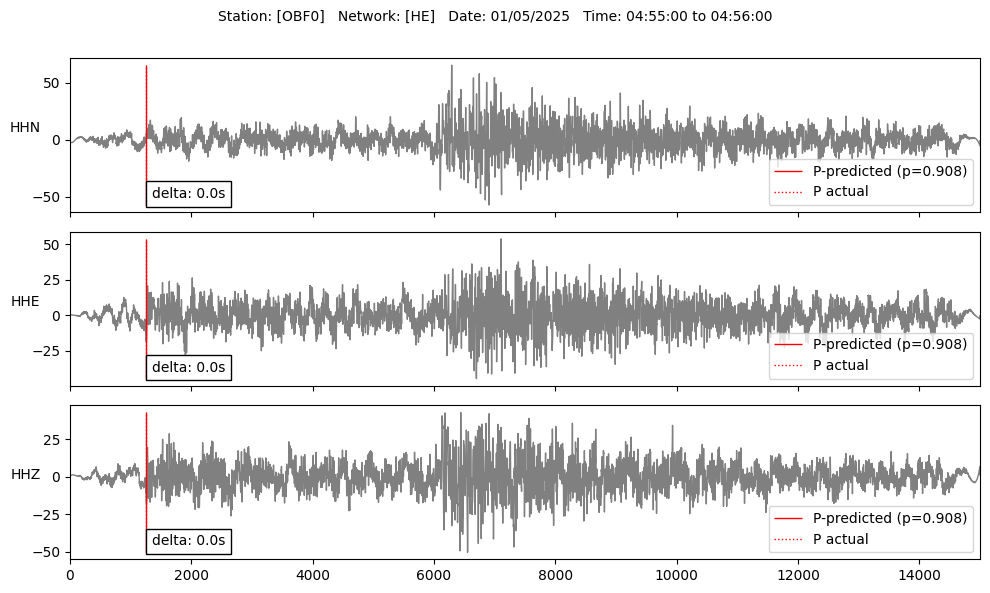

../data/waveforms_earthquakes_nonoise/20250105T045504Z_20250105T045604Z/OBF3


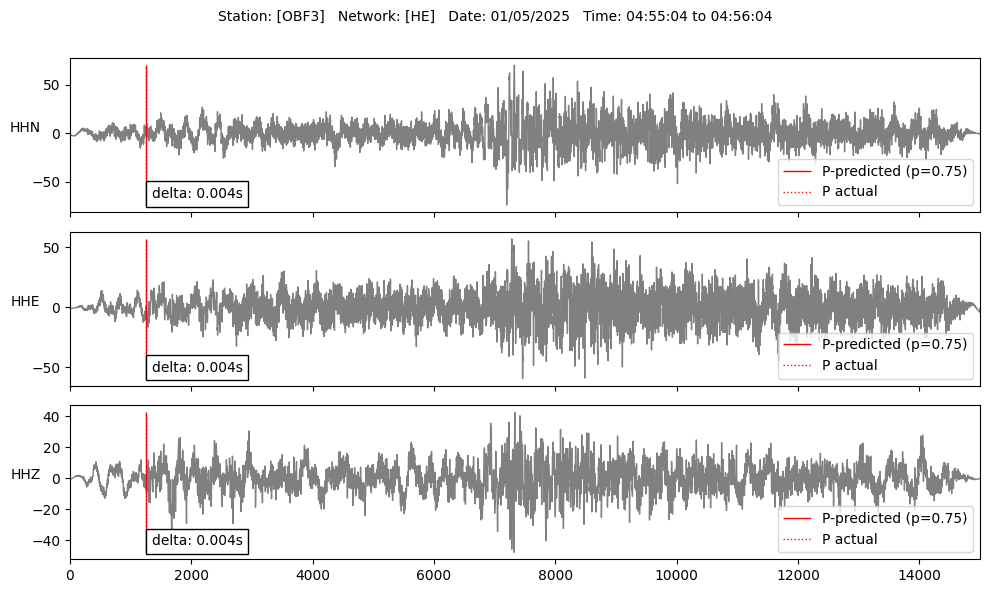

../data/waveforms_earthquakes_nonoise/20250105T045508Z_20250105T045608Z/ALAJF


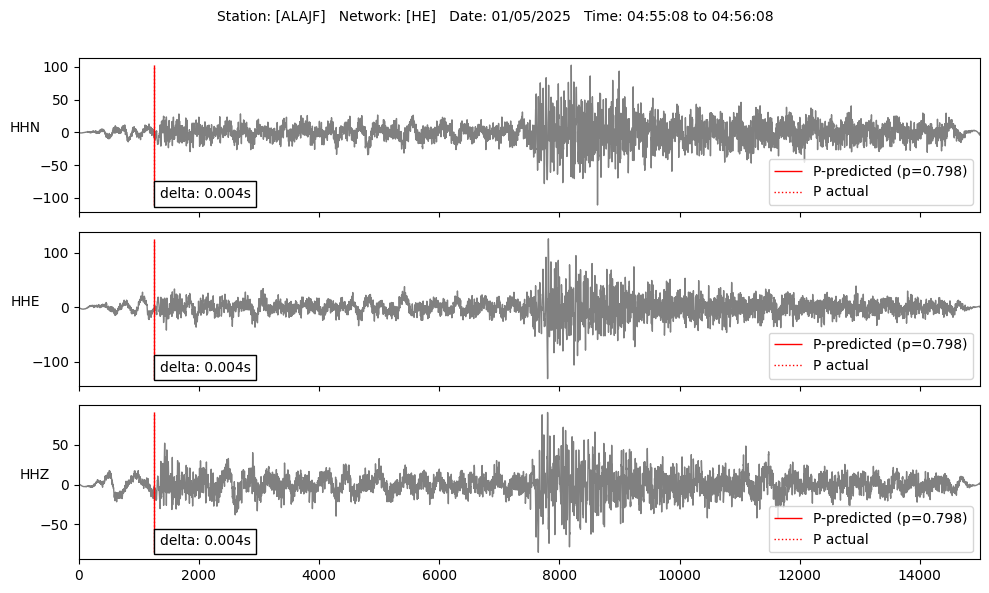

../data/waveforms_earthquakes_nonoise/20250105T045454Z_20250105T045554Z/OBF8


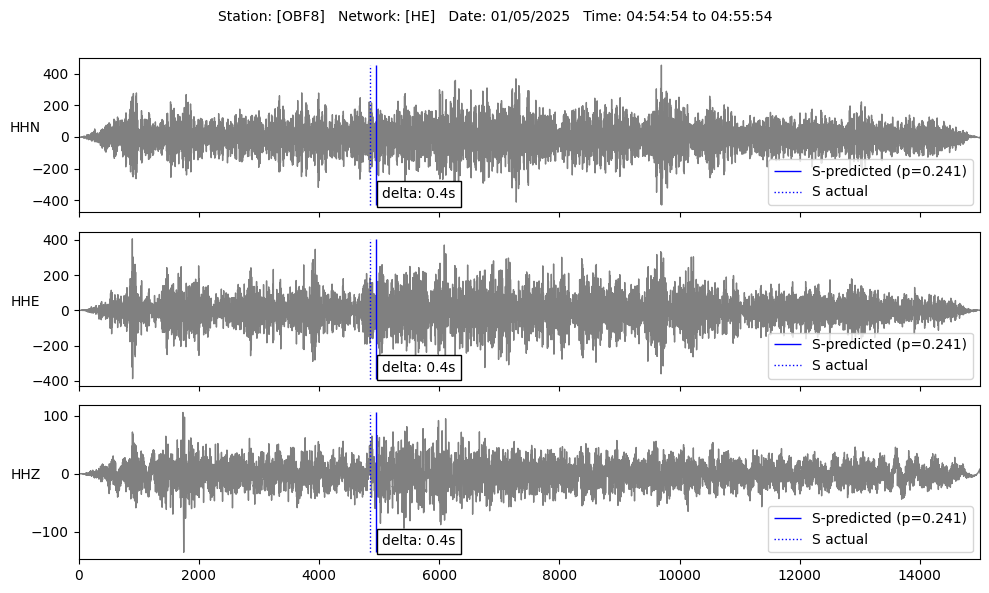

../data/waveforms_earthquakes_nonoise/20250105T045500Z_20250105T045600Z/OBF0


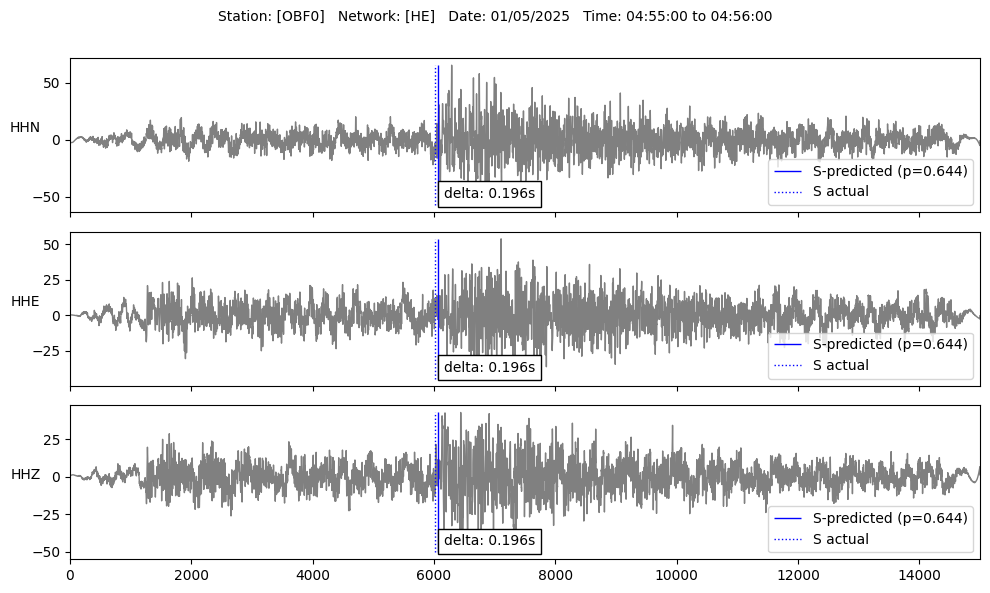

../data/waveforms_earthquakes_nonoise/20250105T045504Z_20250105T045604Z/OBF3


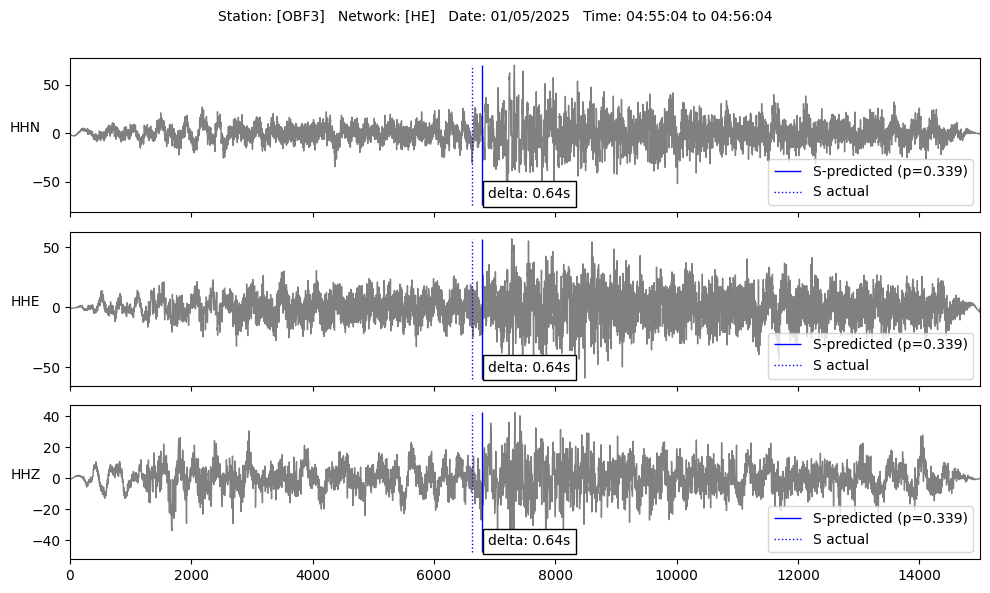

../data/waveforms_earthquakes_nonoise/20250105T045508Z_20250105T045608Z/ALAJF


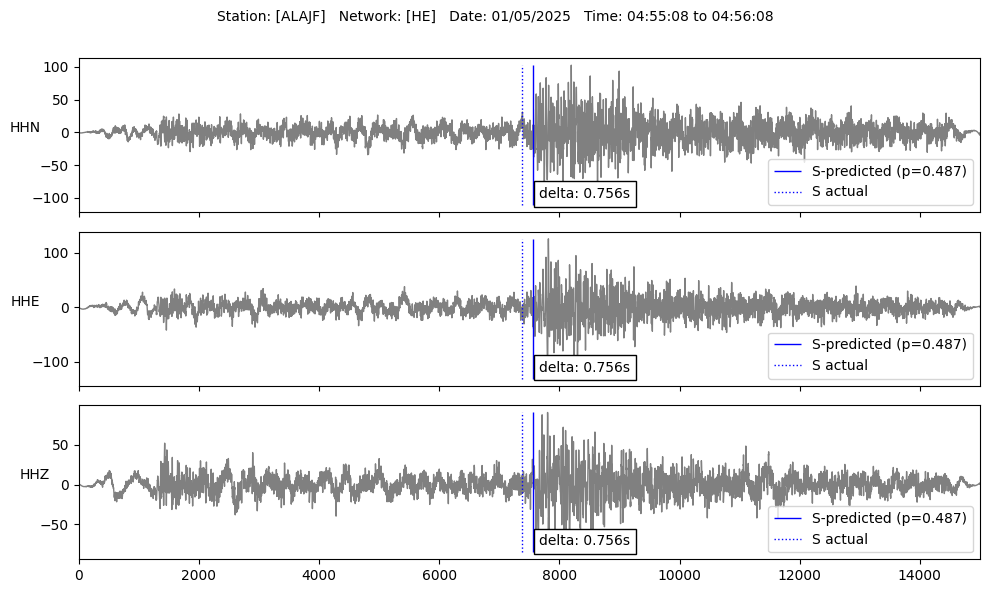

In [ ]:
# Path for .mseed data
data_dir = "../data/waveforms_earthquakes_nonoise/"
df = pd.read_csv(csv_output_path + csv_output_name)

# Currently predictions are seemingly only for one of three channels
# This is a workaround for loading all three channels
channels = ["HHN", "HHE", "HHZ"]

for i in range(50):
    if pd.notna(preds_on_picks["event_id"][i]):
        # Strings for assembling the filename
        station = preds_on_picks["station"][i]
        network = preds_on_picks["network"][i]
        start_dt = UTCDateTime(preds_on_picks["start_dt"][i]).strftime("%Y%m%dT%H%M%SZ")
        end_dt = UTCDateTime(preds_on_picks["end_dt"][i]).strftime("%Y%m%dT%H%M%SZ")

        # Construct the time window folder
        time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")
        print(time_window_dir)
        st = []

        for channel in channels:
            # Create filepath for each channel
            filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
            filepath = os.path.join(time_window_dir, filename)

            # Add each channel to the stream (if available)
            if os.path.exists(filepath):
                st += read(filepath)
            else:
                print(f"Warning: {filepath} not found")

        # Extract date and time information
        starttime = st[0].stats.starttime
        endtime = st[0].stats.endtime
        sampling_rate = st[0].stats.sampling_rate
        window_date = starttime.strftime("%m/%d/%Y")
        window_start = starttime.strftime("%H:%M:%S")
        window_end = endtime.strftime("%H:%M:%S")
        
        # If there is a predicted arrival time, determine the picks by computing the waveform sample index
        predP = None
        predS = None
        refP = None
        refS = None

        if pd.notna(preds_on_picks["pred_arrival_time"][i]):
            if preds_on_picks["phase"][i] == "P":
                predP = int((UTCDateTime(preds_on_picks["pred_arrival_time"][i]) - starttime) * sampling_rate)
                refP = int((UTCDateTime(preds_on_picks["true_arrival_time"][i]) - starttime) * sampling_rate)
            elif preds_on_picks["phase"][i] == "S":
                predS = int((UTCDateTime(preds_on_picks["pred_arrival_time"][i]) - starttime) * sampling_rate)
                refS = int((UTCDateTime(preds_on_picks["true_arrival_time"][i]) - starttime) * sampling_rate)
        
        # === Plotting ===
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
        # Event info to generate a plot title
        event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
        fig.suptitle(event_info,fontsize=10)

        for j, channel in enumerate(channels):
            # Get sampling rate
            sampling_rate = st[j].stats.sampling_rate

            # Copy the trace for processing
            tr_filt = st[j].copy()

            # Processing/filtering
            tr_filt.detrend("linear")
            tr_filt.detrend("demean")
            tr_filt.taper(max_percentage=0.05)
            tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

            ax = axes[j]
            ax.plot(tr_filt.data, color="grey", linewidth=1)
            
            # Get the min and max y values
            y_min = tr_filt.data.min()
            y_max = tr_filt.data.max()
            text_pos = y_min + (y_max - y_min)/20
            
            # Plot vertical lines for predicted p- and s-wave arrivals
            if predP is not None:
                ax.vlines(predP, y_min, y_max, color='r', linewidth=1, label=f'P-predicted (p={preds_on_picks["probability"][i]})')
                ax.vlines(refP, y_min, y_max, color='r', linewidth=1, linestyles='dotted', label=f'P actual')
                ax.text(x=predP+100, y=text_pos, s=f"delta: {(predP-refP)/sampling_rate}s", bbox=dict(facecolor='w', alpha=1))
            if predS is not None:
                ax.vlines(predS, y_min, y_max, color='b', linewidth=1, label=f'S-predicted (p={preds_on_picks["probability"][i]})')
                ax.vlines(refS, y_min, y_max, color='b', linewidth=1, linestyles='dotted', label=f'S actual')
                ax.text(x=predS+100, y=text_pos, s=f"delta: {(predS-refS)/sampling_rate}s", bbox=dict(facecolor='w', alpha=1))
            # Set x limit
            ax.set_xlim(0, len(tr_filt.data))
            ax.set_ylabel(channel, rotation="horizontal")
            ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

## Plot some "False Negatives" as they may be earthquakes missed by human pickers

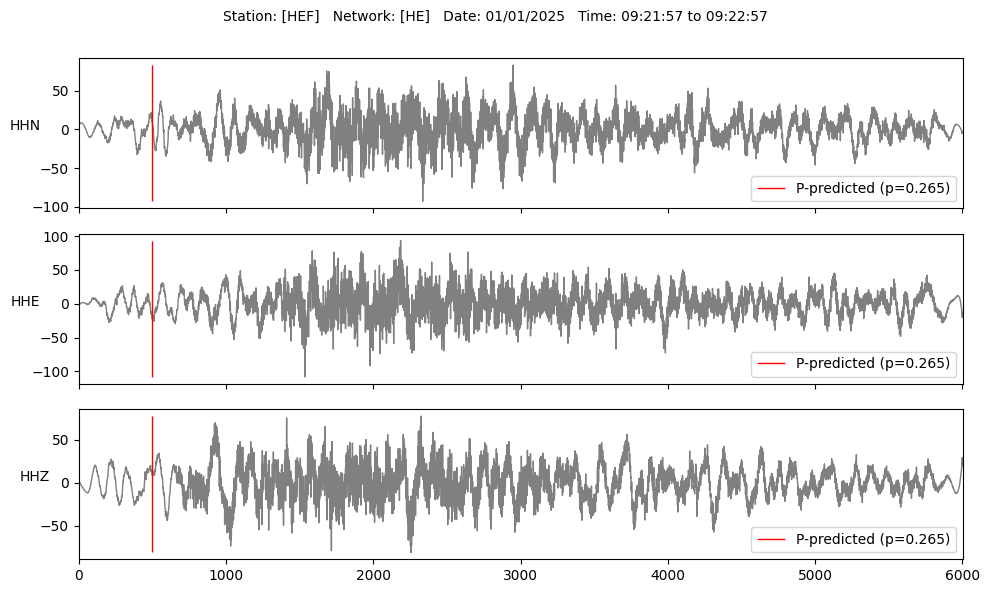

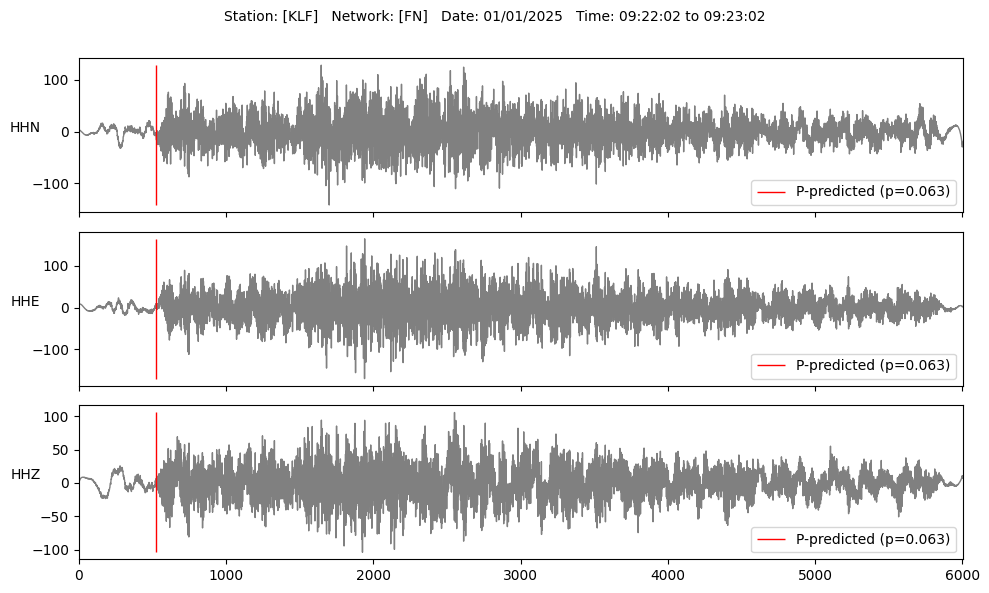

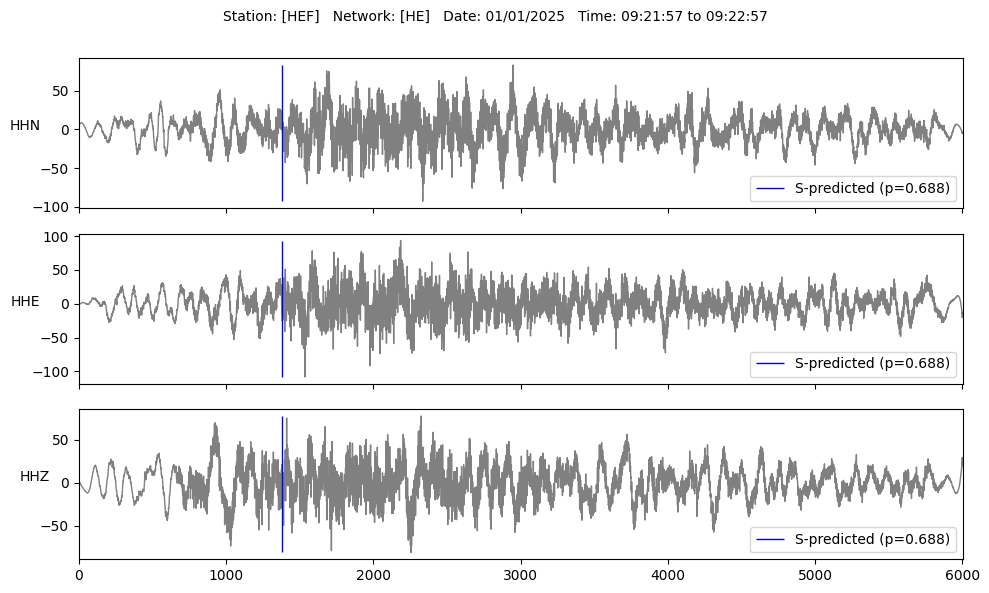

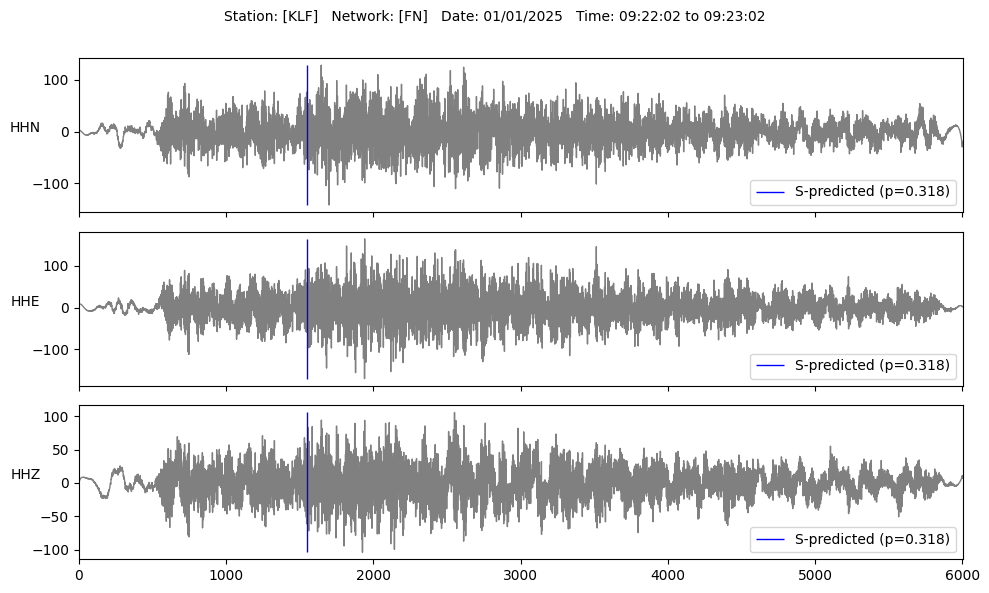

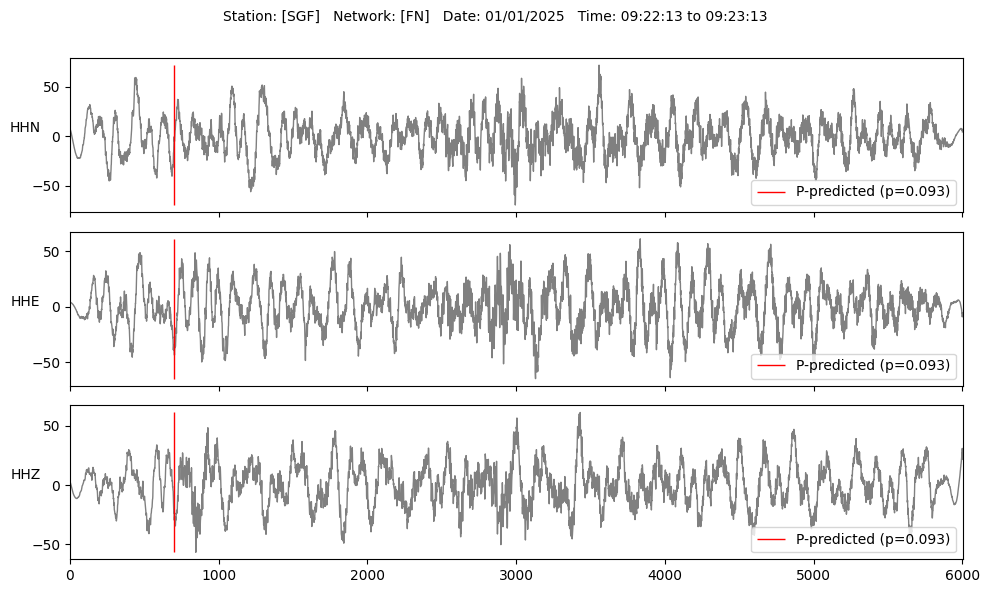

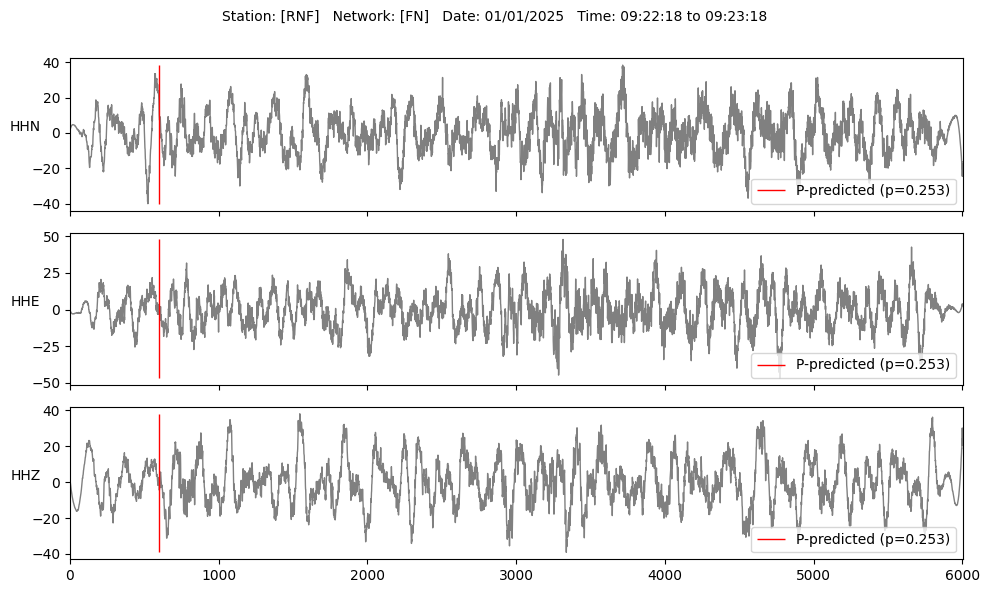

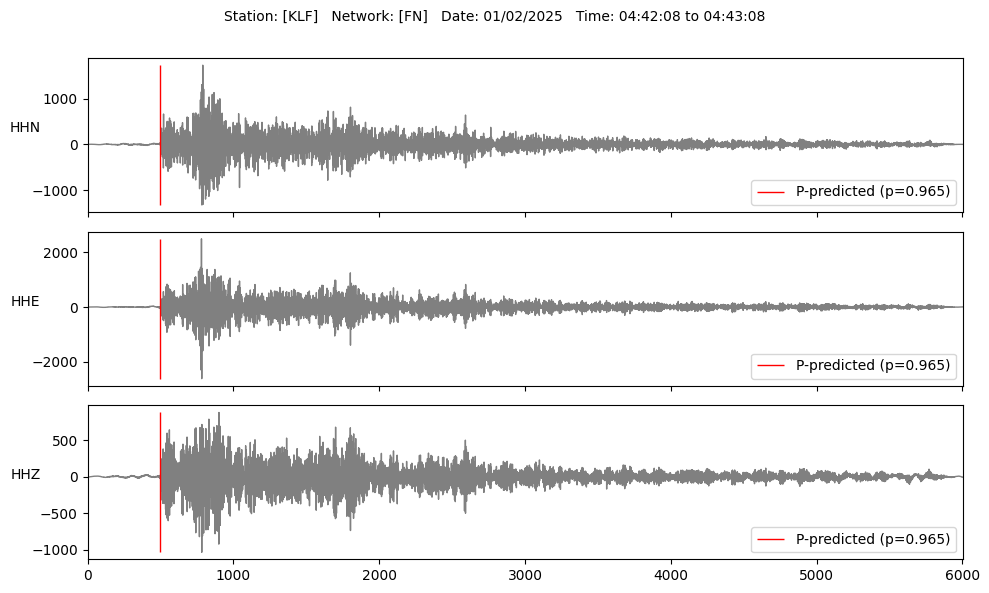

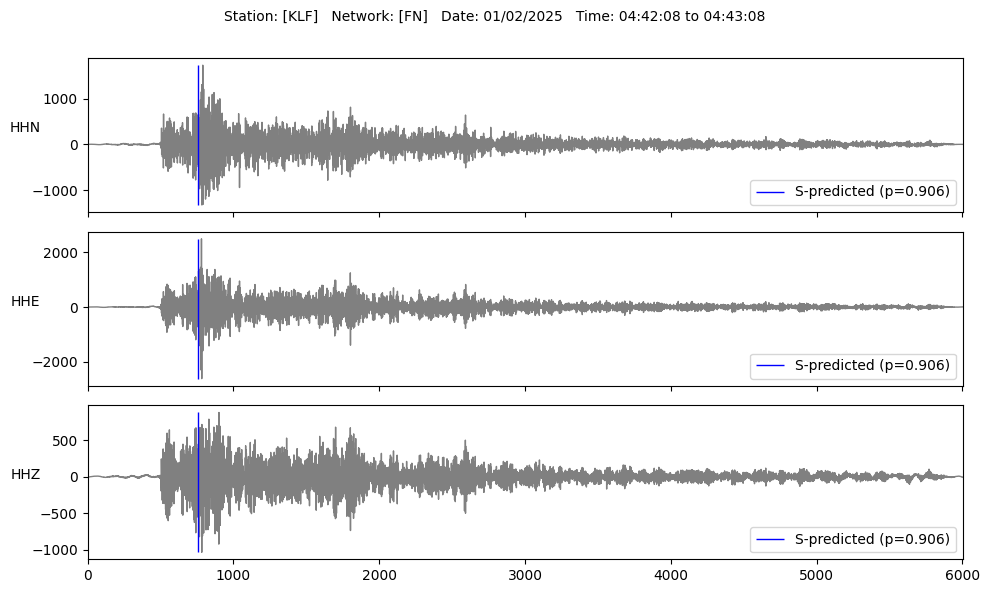

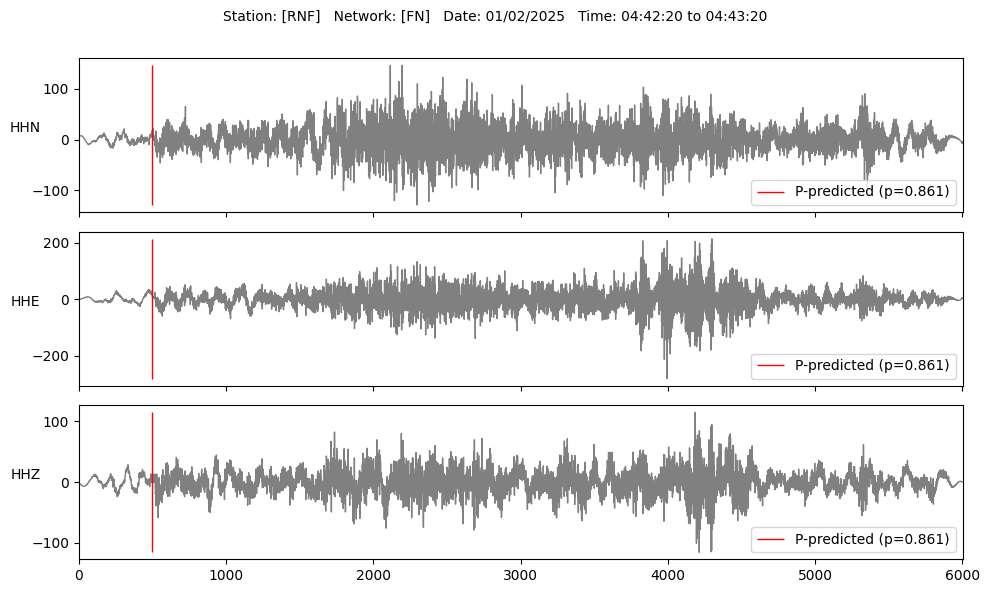

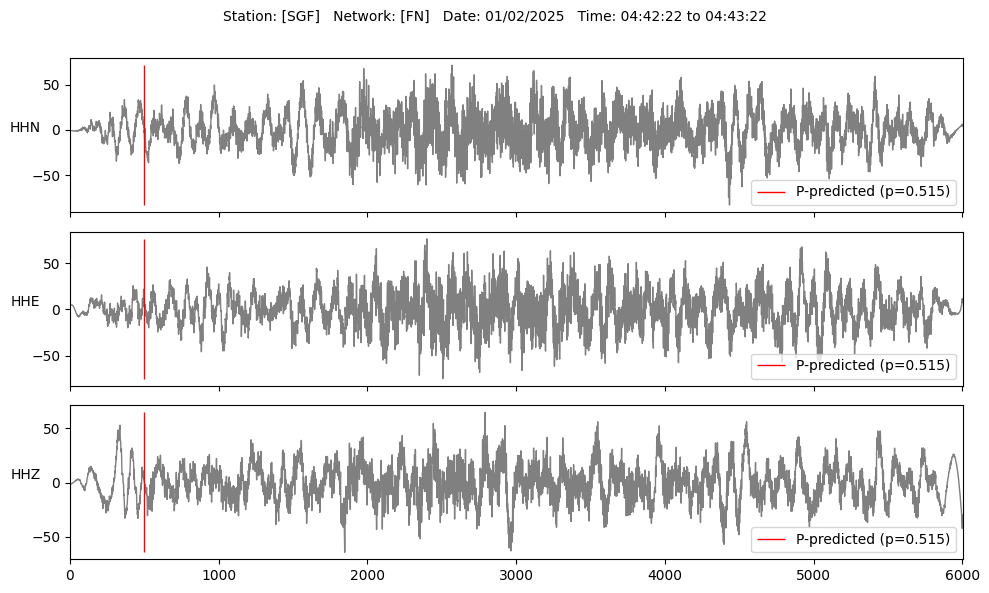

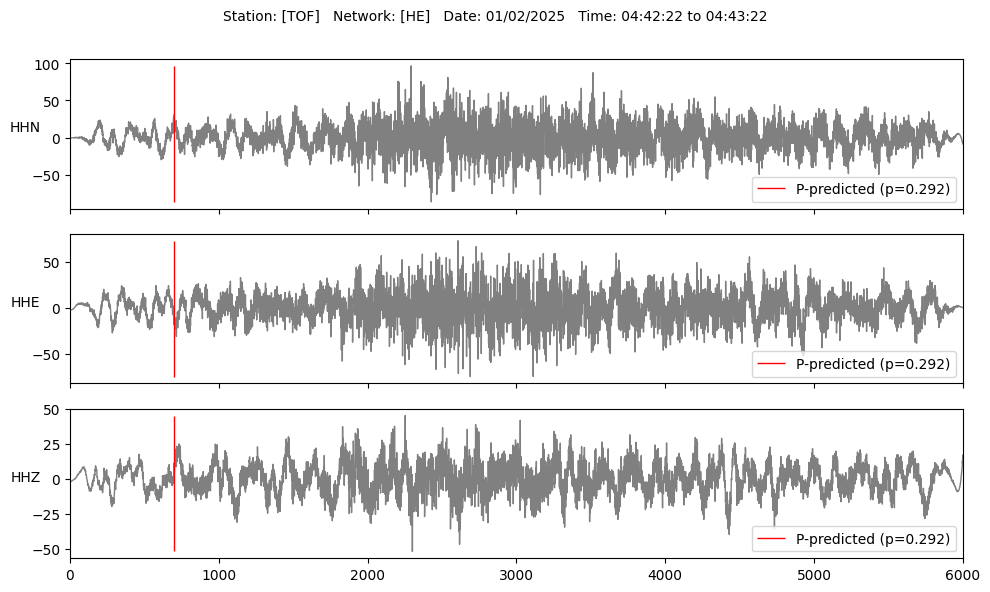

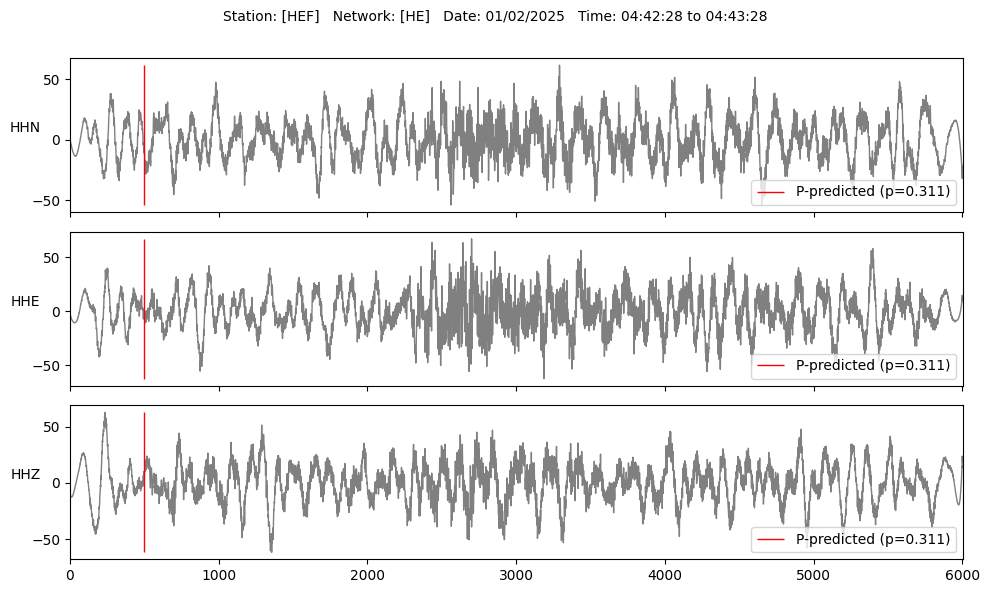

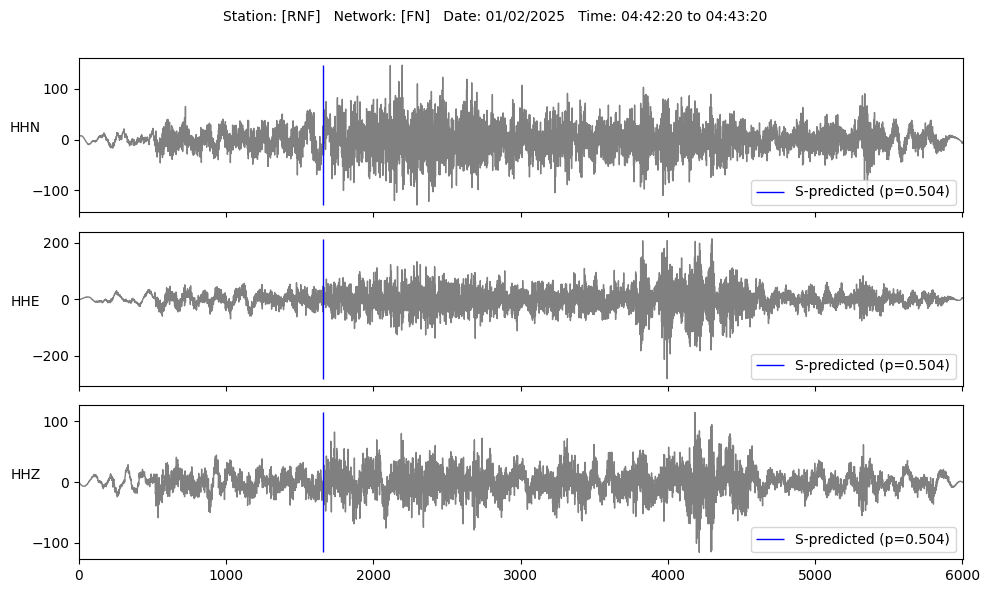

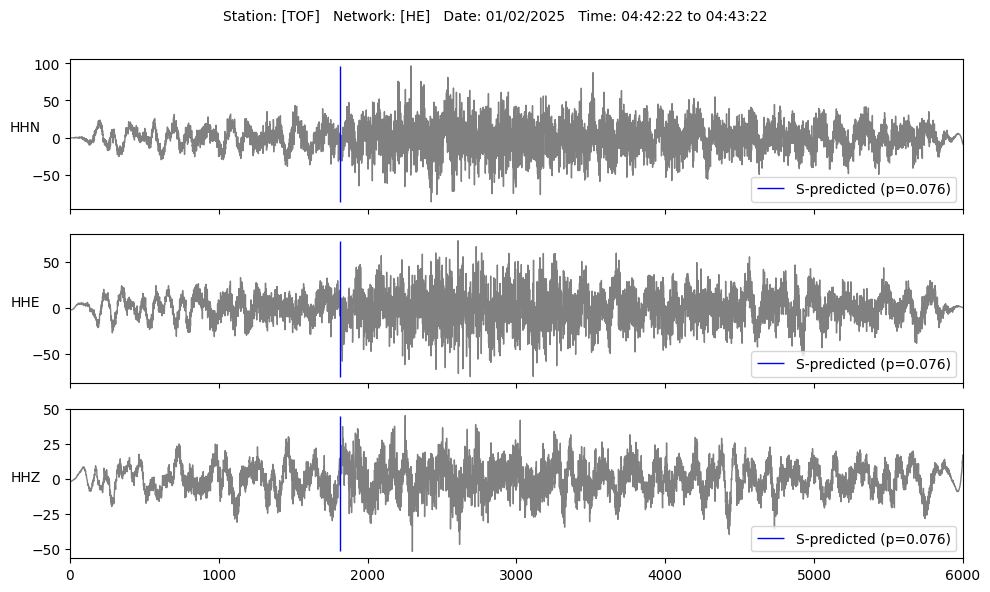

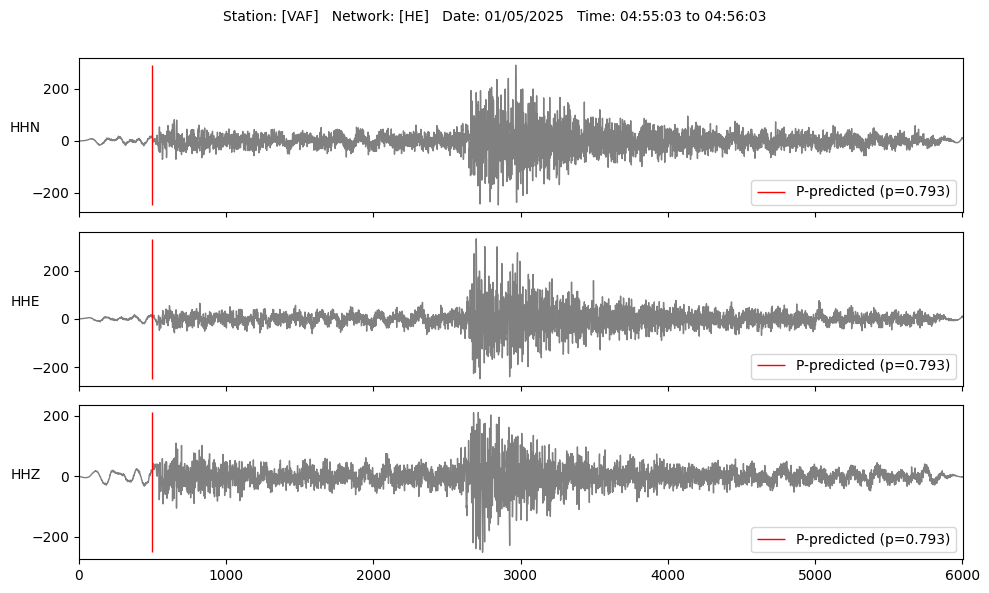

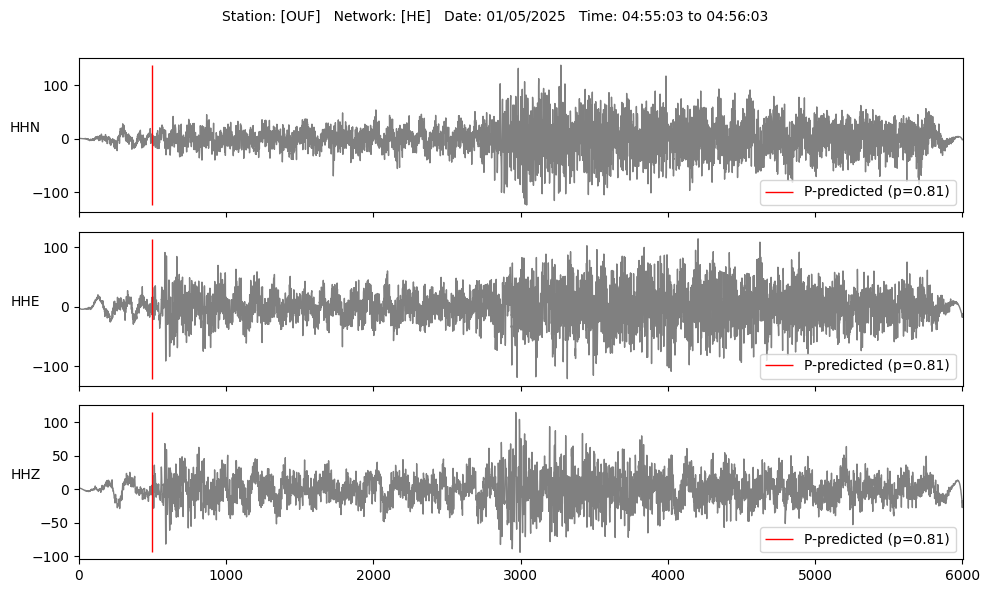

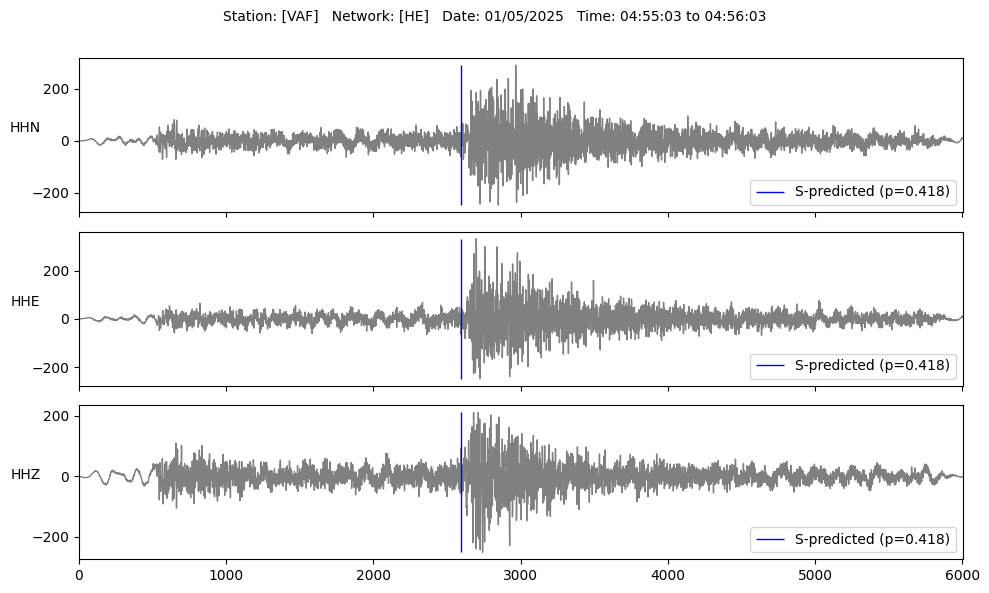

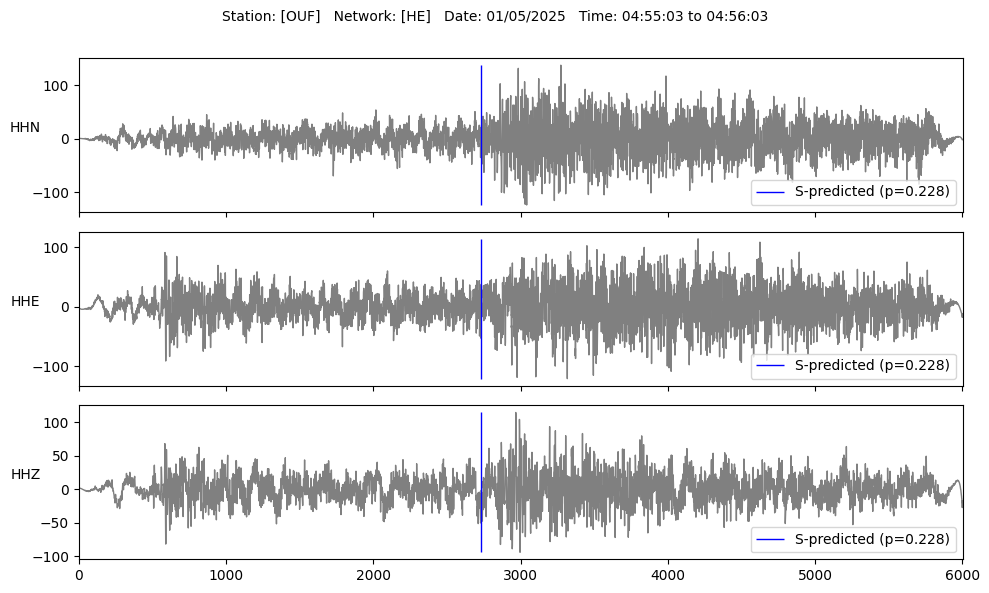

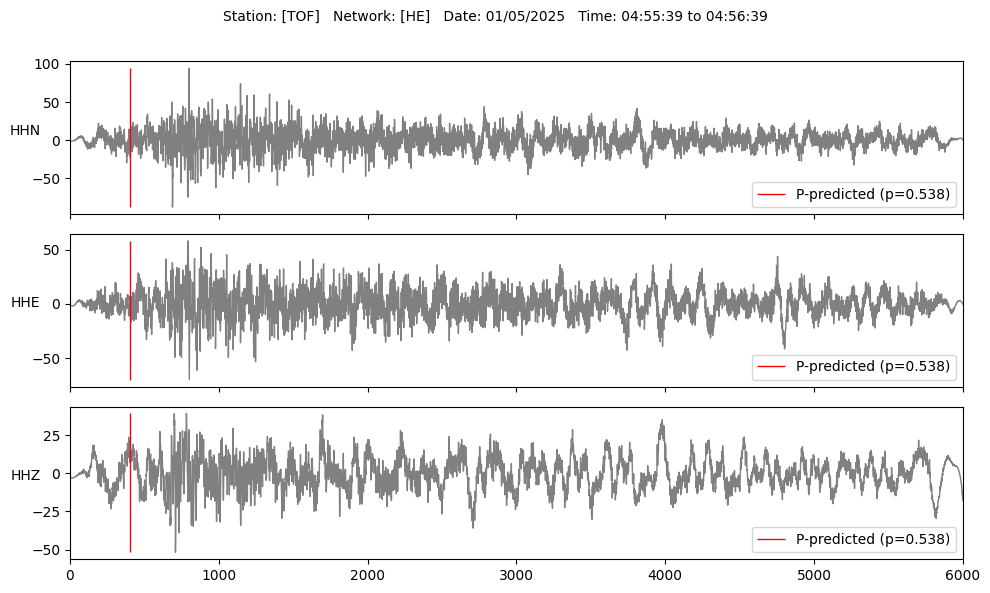

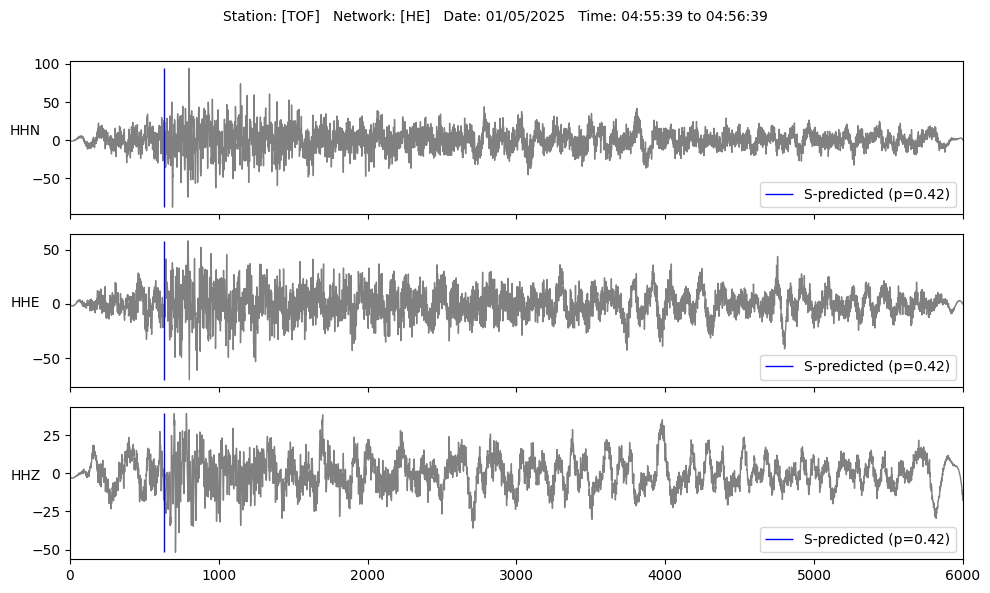

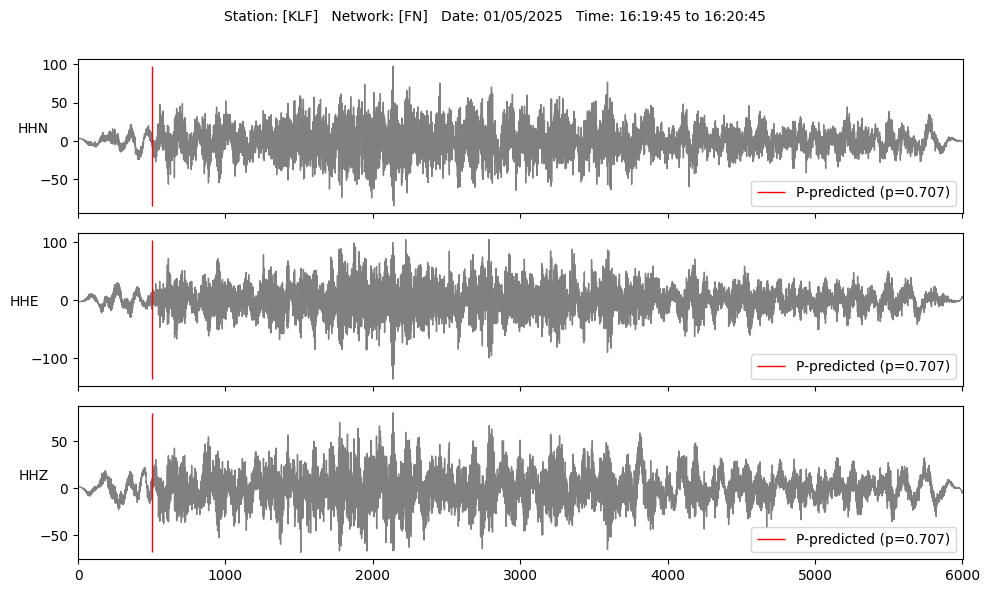

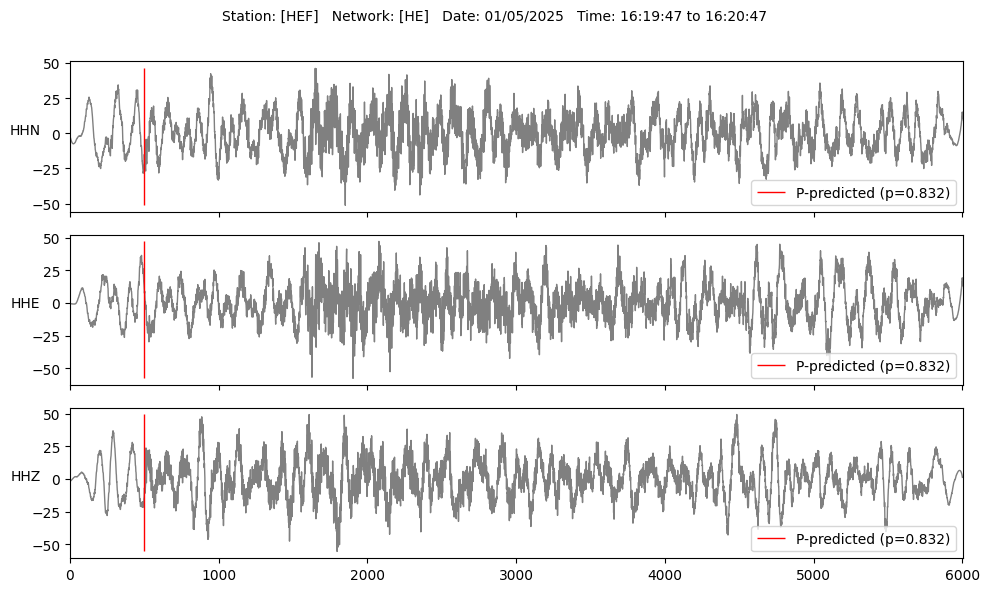

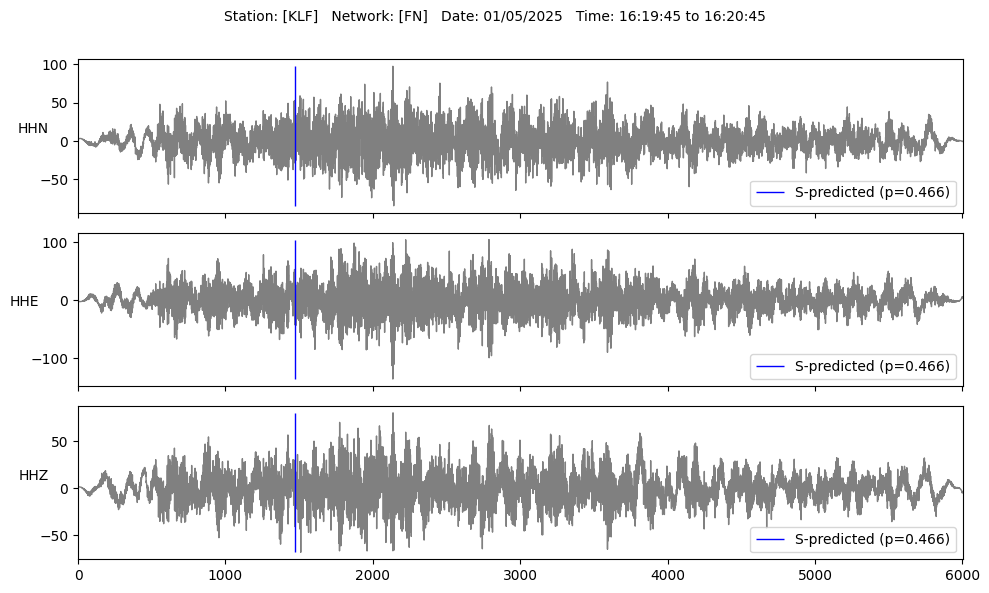

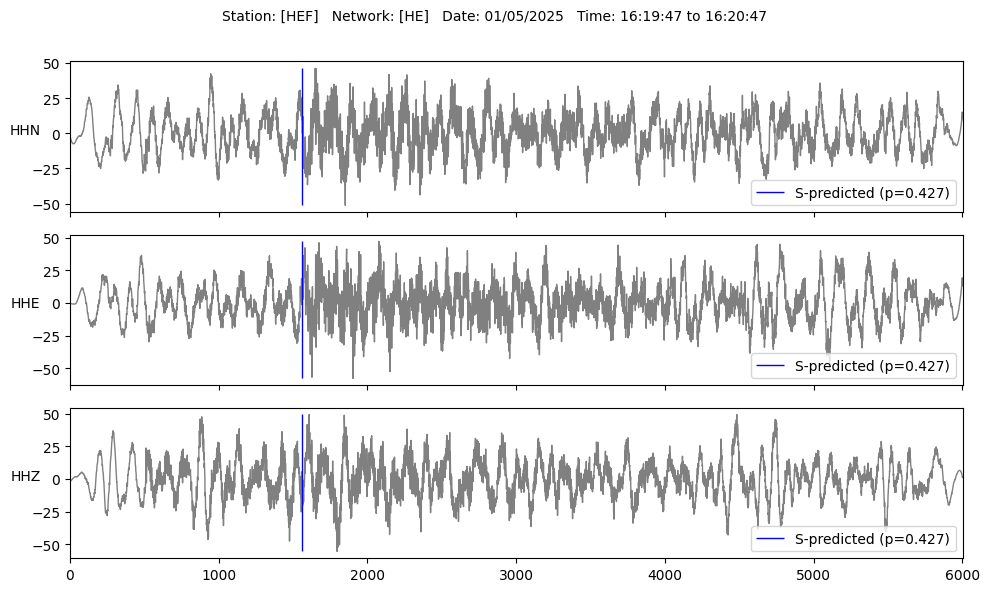

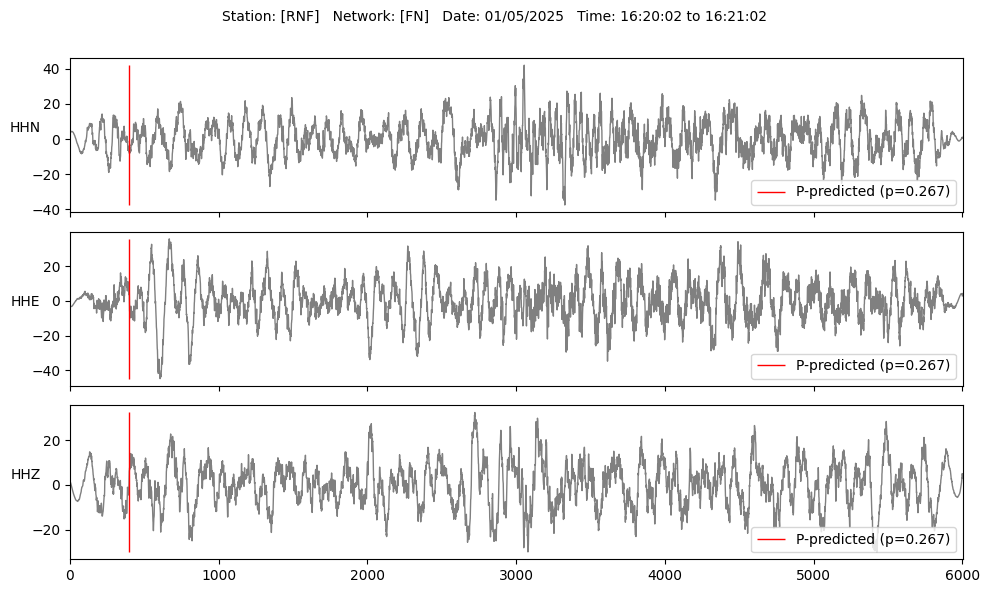

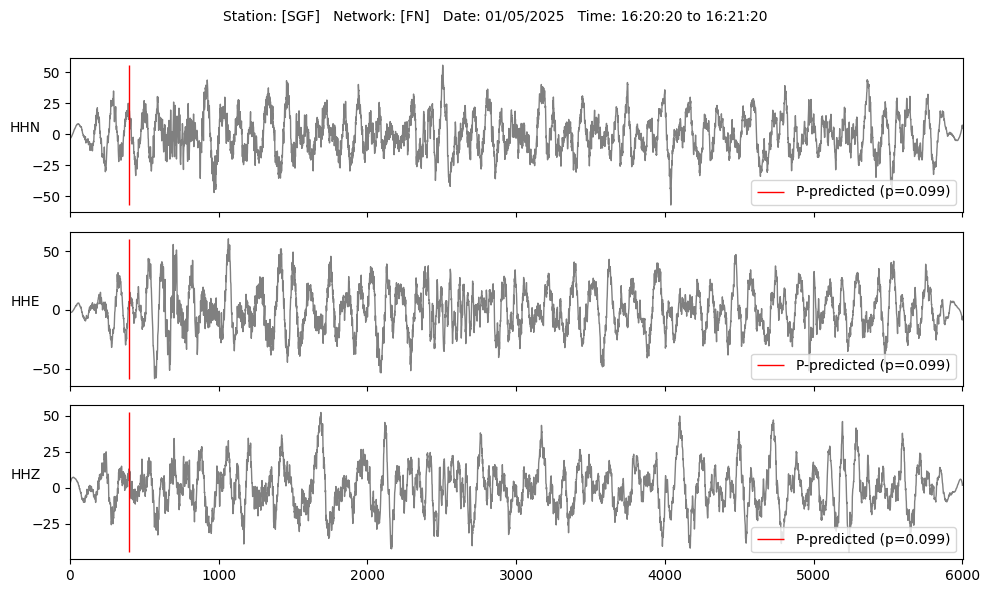

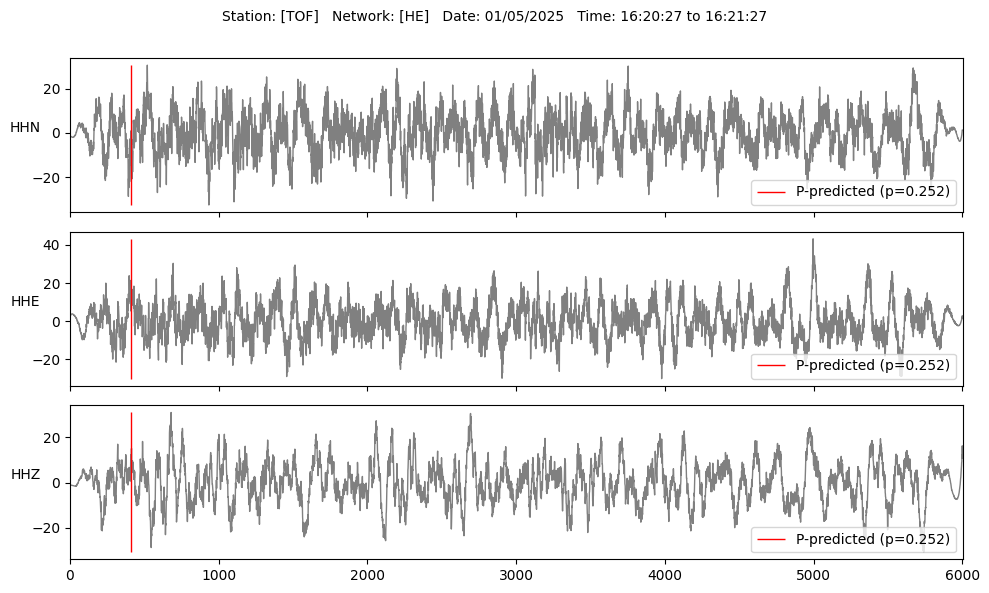

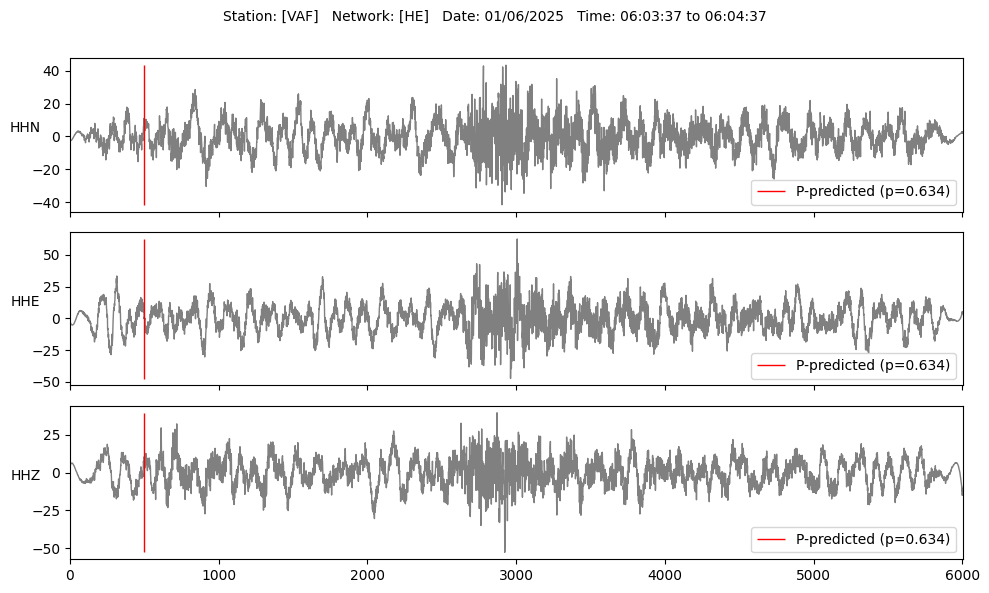

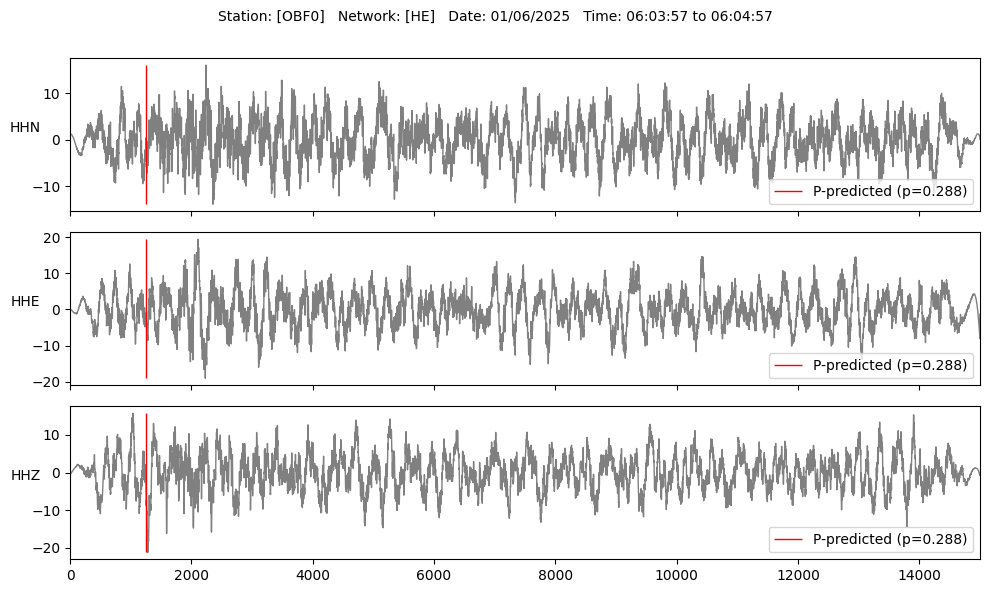

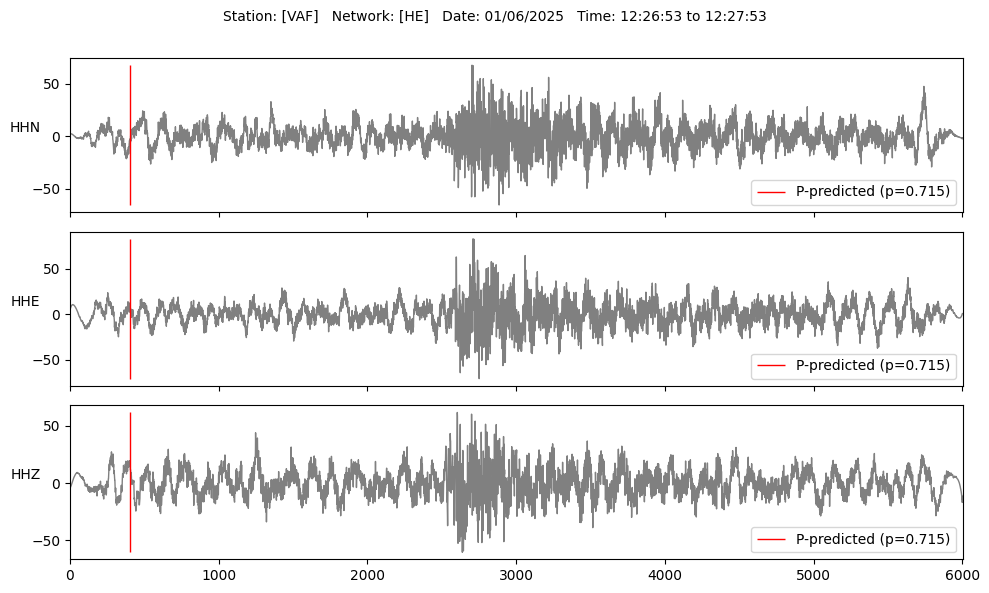

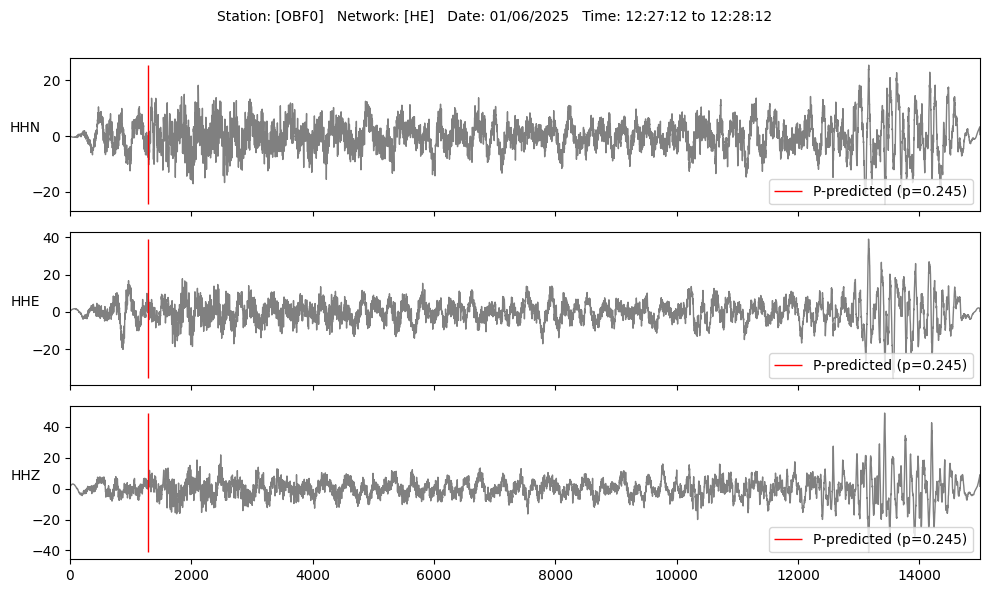

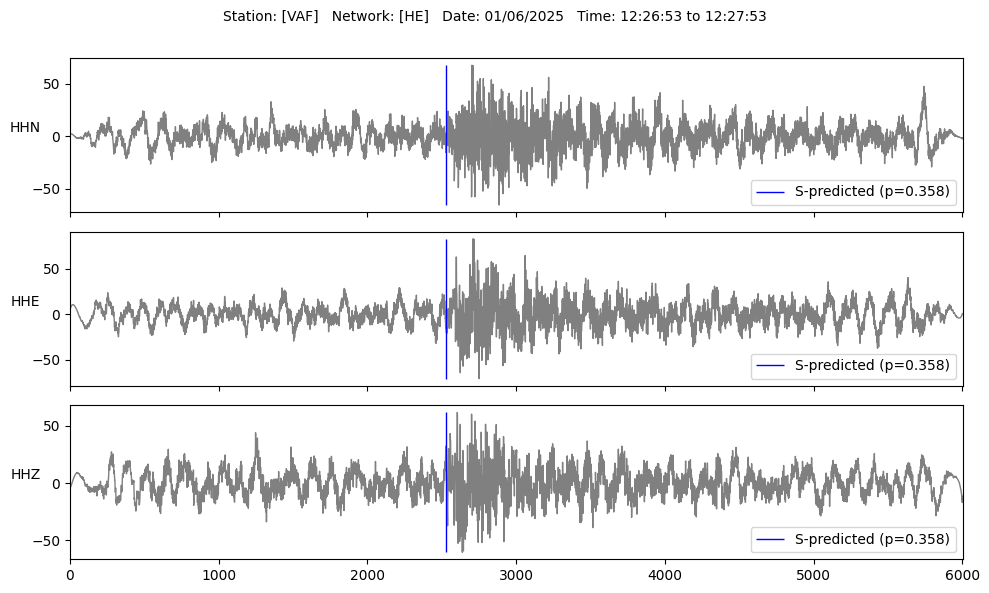

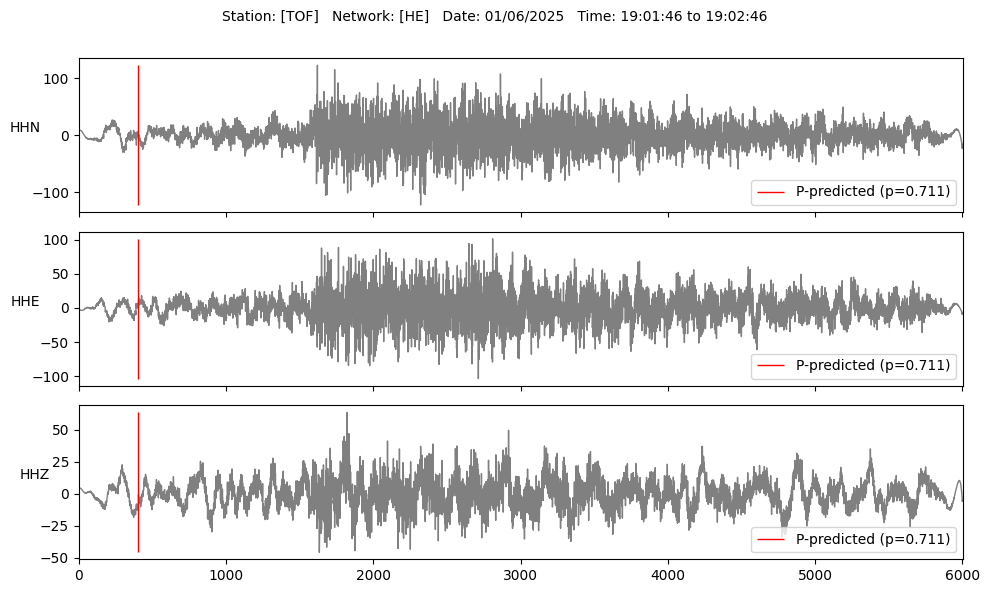

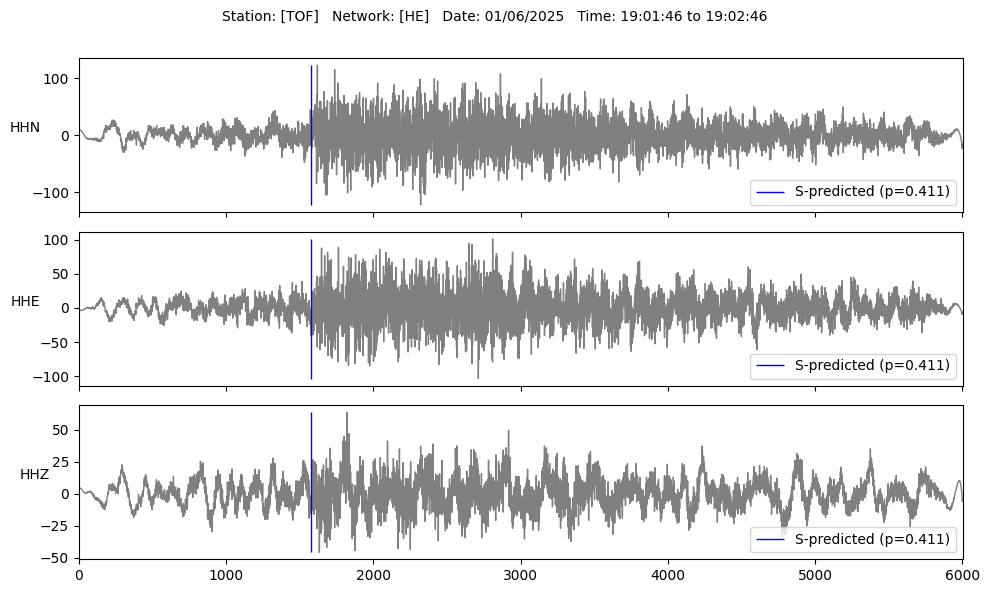

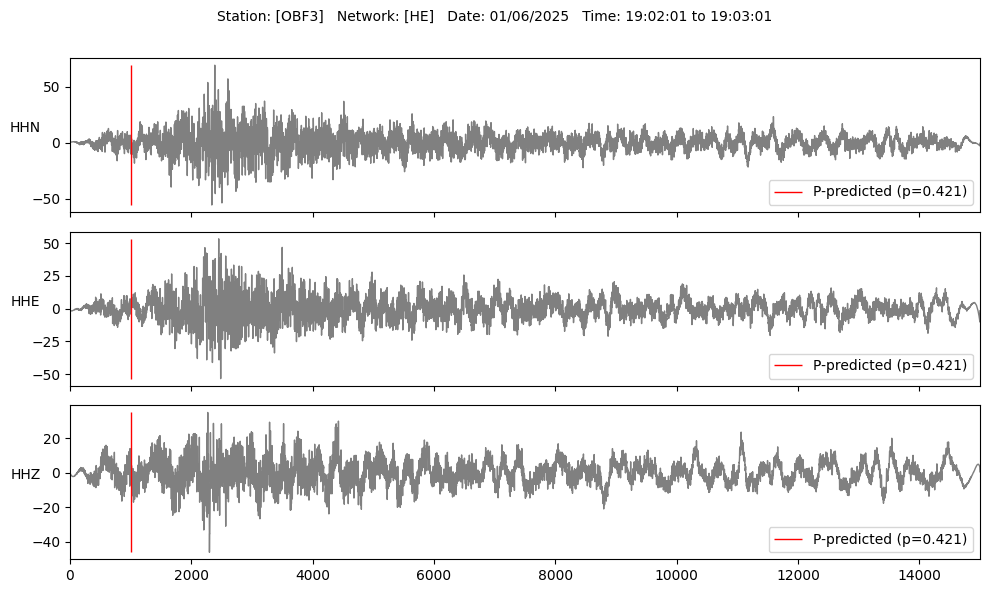

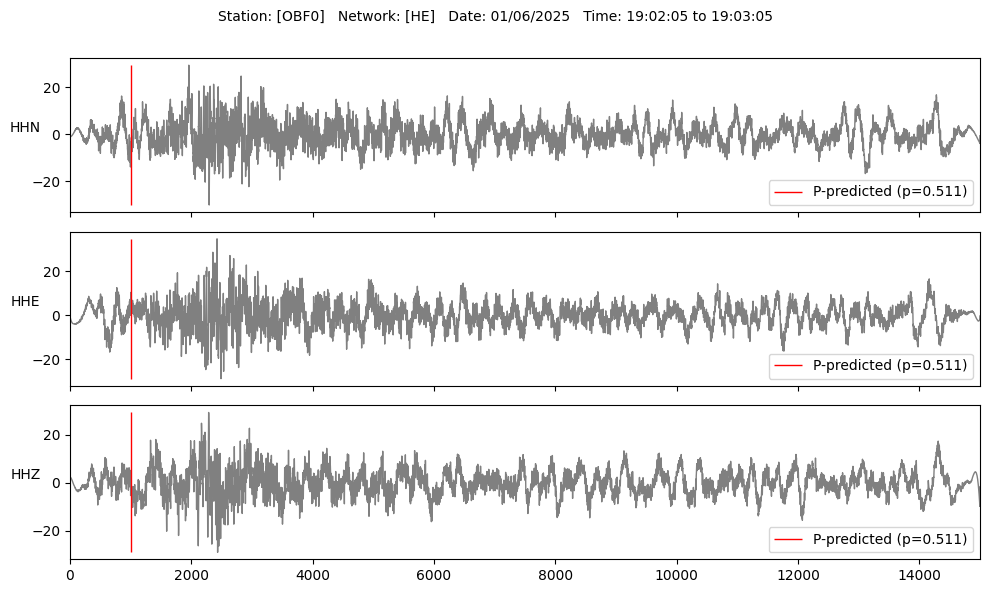

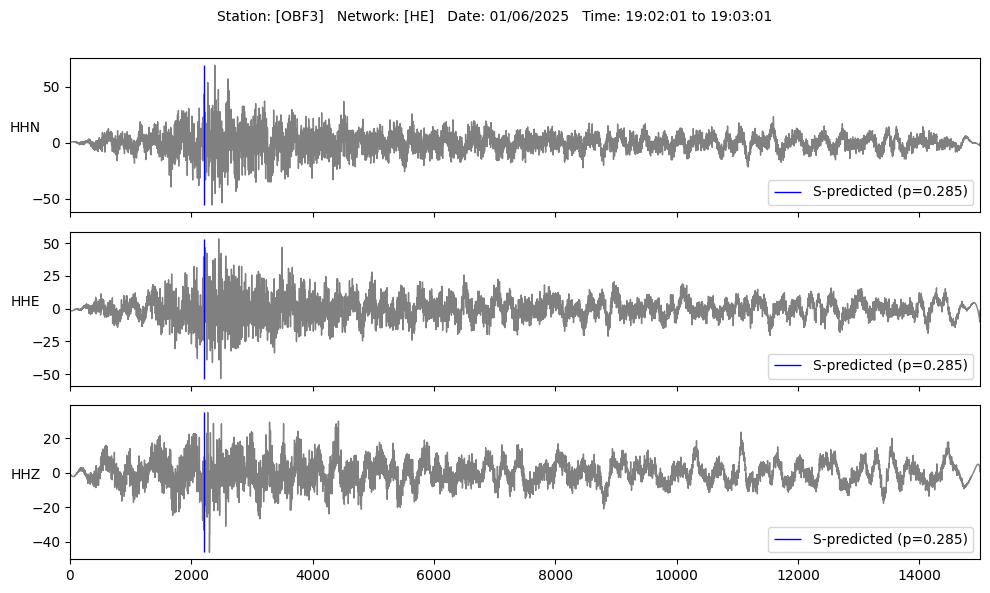

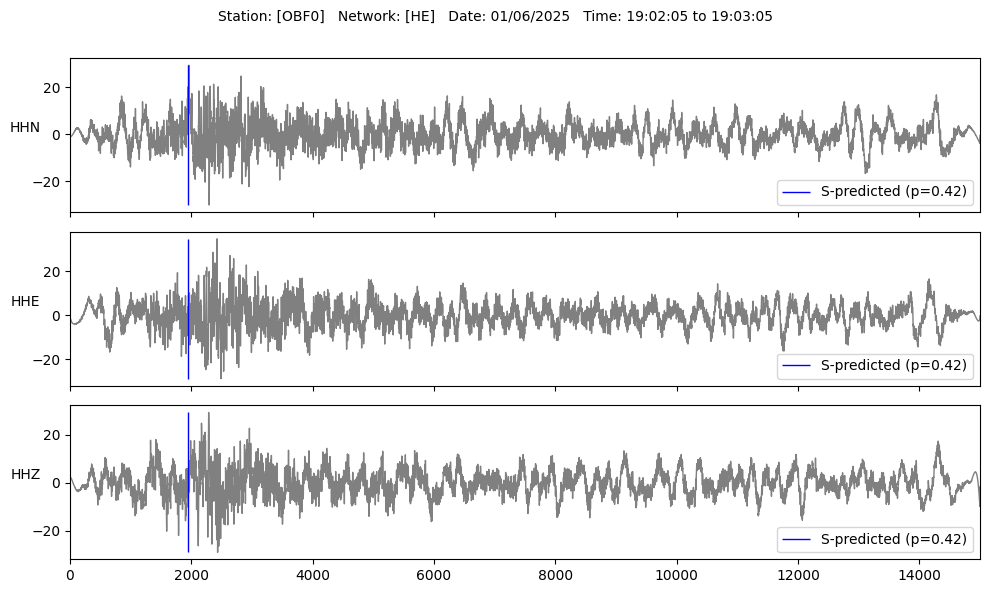

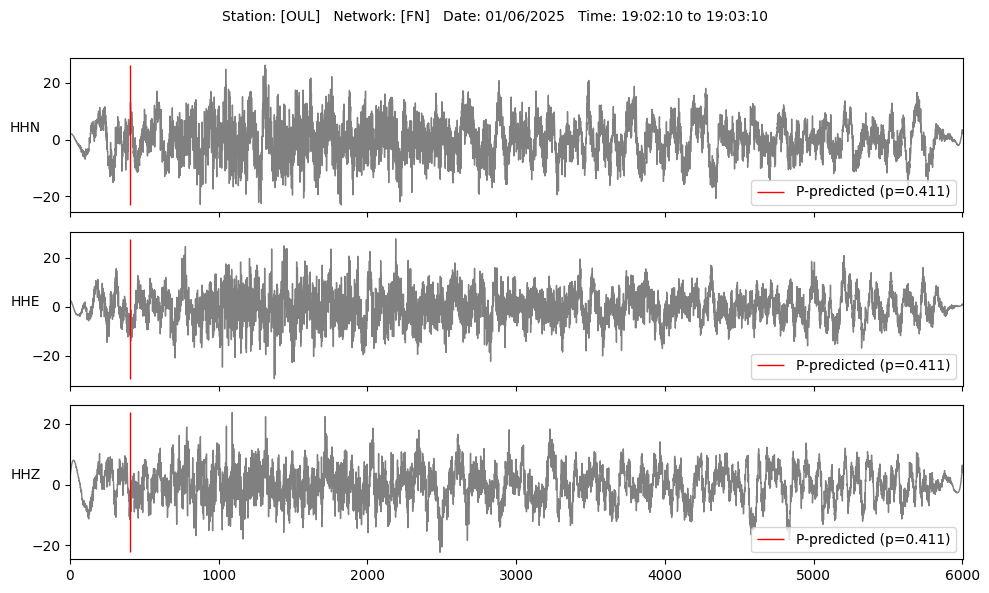

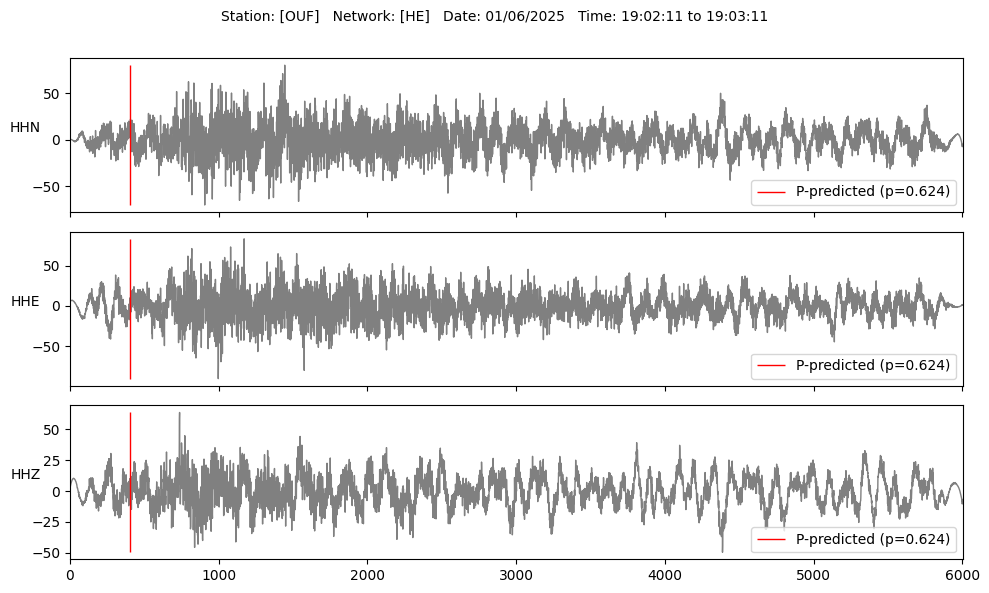

In [77]:
# Plot some "False Negatives"
for i in range(50):
    if pd.isna(preds_on_picks["event_id"][i]):
        # Strings for assembling the filename, strip spaces just in case
        station = preds_on_picks["station"][i].strip()
        network = preds_on_picks["network"][i].strip()
        start_dt = UTCDateTime(preds_on_picks["start_dt"][i]).strftime("%Y%m%dT%H%M%SZ")
        end_dt = UTCDateTime(preds_on_picks["end_dt"][i]).strftime("%Y%m%dT%H%M%SZ")

        # Construct the time window folder
        time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")
        st = []

        for channel in channels:
            # Create filepath for each channel
            filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
            filepath = os.path.join(time_window_dir, filename)

            # Add each channel to the stream (if available)
            if os.path.exists(filepath):
                st += read(filepath)
            else:
                print(f"Warning: {filepath} not found")

        # Extract date and time information
        starttime = st[0].stats.starttime
        endtime = st[0].stats.endtime
        sampling_rate = st[0].stats.sampling_rate
        window_date = starttime.strftime("%m/%d/%Y")
        window_start = starttime.strftime("%H:%M:%S")
        window_end = endtime.strftime("%H:%M:%S")
        
        # If there is a predicted arrival time, determine the picks by computing the waveform sample index
        predP = None
        predS = None

        if pd.notna(preds_on_picks["pred_arrival_time"][i]):
            if preds_on_picks["phase"][i] == "P":
                predP = int((UTCDateTime(preds_on_picks["pred_arrival_time"][i]) - starttime) * sampling_rate)
            elif preds_on_picks["phase"][i] == "S":
                predS = int((UTCDateTime(preds_on_picks["pred_arrival_time"][i]) - starttime) * sampling_rate)
        
        # === Plotting ===
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
        # Event info to generate a plot title
        event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
        fig.suptitle(event_info,fontsize=10)

        for j, channel in enumerate(channels):
            # Get sampling rate
            sampling_rate = st[j].stats.sampling_rate

            # Copy the trace for processing
            tr_filt = st[j].copy()

            # Processing/filtering
            tr_filt.detrend("linear")
            tr_filt.detrend("demean")
            tr_filt.taper(max_percentage=0.05)
            tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

            ax = axes[j]
            ax.plot(tr_filt.data, color="grey", linewidth=1)
            
            # Get the min and max y values
            y_min = tr_filt.data.min()
            y_max = tr_filt.data.max()
            text_pos = y_min + (y_max - y_min)/20
            
            # Plot vertical lines for predicted p- and s-wave arrivals
            if predP is not None:
                ax.vlines(predP, y_min, y_max, color='r', linewidth=1, label=f'P-predicted (p={preds_on_picks["probability"][i]})')
            if predS is not None:
                ax.vlines(predS, y_min, y_max, color='b', linewidth=1, label=f'S-predicted (p={preds_on_picks["probability"][i]})')
            # Set x limit
            ax.set_xlim(0, len(tr_filt.data))
            ax.set_ylabel(channel, rotation="horizontal")
            ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()